In [743]:
import sys

import vis_plotting as vis_plt
import EAVILS_processing
import my_utils
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as lines
import matplotlib_venn 
from matplotlib.patches import Circle


import scipy
import os
import yaml
import copy
import pandas as pd
import bidict

import astropy.io.fits as fits
from astropy.coordinates import Angle
from astropy import units as u
from astropy.time import Time



# The following establishes a few initial parameters

In [2]:
#For now this is still necessary to handle pointing information. In future versions this should be contained as metadata in h5 files
metafits_folders = 'testing_tutorial/metafits/'

#Flagging the coarse band lines for the MWA. In general this parameter can be used for flagging coarse-band lines,
#or things like known FM or satellite contaminated channels
permanent_flags = my_utils.coarse_band_flagging()

#This shape_dict is taken from SSINS, with an additional "subTV" pseudo-channel added as a control "clean channel". 
#This subTV channel is quite simply the frequencies below which the digital TV channels live
shape_dict = my_utils.shape_dict('MWA',add_subTV=True)
#We only want TV channels, so we remove the 'center_packet_loss' frequency type
del shape_dict['center_packet_loss']
print(shape_dict)
#This quite simply sorts our frequency channels based on their minimum frequency
sorted_freq_ranges,sorted_freq_mins = EAVILS_processing.freq_range_sort(shape_dict)
#Establishes the correspondence between polarizations and polarization indices
pol_bidict = bidict.bidict({0:'XX',1:'YY',2:'XY',3:'YX'})


{'TV6': [174000000.0, 181000000.0], 'TV7': [181000000.0, 188000000.0], 'TV8': [188000000.0, 195000000.0], 'TV9': [195000000.0, 202000000.0], 'subTV': [167075000.0, 174000000.0]}


# The following shows how to process raw files into EAVILS h5 files. This compresses the data volume greatly by averaging along baselines.
We dont't include the raw files (in this case UVfits files), and simply shows one example obs_id, but in general all desired data should be processed in this way as an initial step. The output data for this obs_id is included as an example.

In [3]:
all_obs_id_list = ['1160941144']
raw_data_folder = '<raw_data/in/this/folder>'
raw_data_folder = '/Volumes/Data4/elillesk/data_and_analysis/uvfits/chisq_obs/'
for obs_id in all_obs_id_list:
    vis_plt.vis_plotting(obs_id = obs_id,input_data_folder=raw_data_folder,output_path='testing_tutorial/',extension='uvfits')

load_options set to False, options.yml being ignored if it exists
reading  /Volumes/Data4/elillesk/data_and_analysis/uvfits/chisq_obs/1160941144.uvfits
Reading in as a SSINS ss object


diff on read defaults to False now. Please double check SS.read call and ensure the appropriate keyword arguments for your intended use case.


Total number of time indices: 54. Flagged time indices: [ 0 53]. time_cuts set to (1, 53)
trimming times to include indices between: (1, 53)
Antennas found bad via /Volumes/Data4/elillesk/data_and_analysis/uvfits/chisq_obs/1160941144.metafits: [57, 29, 12, 11, 10, 9, 16, 31, 14, 13, 108, 107, 106, 105, 112, 111, 110, 109]
obsid is less than 1318021528, assuming legacy correlator
Preparing data
['cross']


Reordering data array to baseline order to perform differencing.
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide
Mean of empty slice.
invalid value encountered in divide


saving testing_tutorial/output_spectra/1160941144_per_receiver_cross.pdf
saving testing_tutorial/output_spectra/1160941144_output_spectra_cross.pdf




The input directory should be set to the output_path of vis_plotting, in the h5_files subdirectory. Again, here we just have one example file in this folder, but if the previous step is executed on a set of raw files, this directory should contain the EAVILS h5 files needed to further process the data.

In [4]:
#input_directory = 'testing_tutorial/h5_files/'
input_directory = '/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files/'

In [5]:
list_file_directory = 'example_obs_lists_split'

In [6]:
print(os.listdir(list_file_directory))

['11-17-2016-EOR0.txt', '10-30-2016-EOR0.txt', '10-30-2016-EOR1.txt', '12-15-2016-EOR0.txt', '10-19-2016-EOR1.txt', '10-19-2016-EOR0.txt', '10-17-2016-EOR1.txt', '10-17-2016-EOR0.txt', '11-19-2016-EOR0.txt', '10-15-2016-EOR0.txt', '10-28-2016-EOR1.txt', '10-28-2016-EOR0.txt', '10-15-2016-EOR1.txt', '11-21-2016-EOR0.txt', '.ipynb_checkpoints', '10-21-2016-EOR0.txt', '10-21-2016-EOR1.txt', '10-22-2016-EOR0.txt', '11-12-2016-EOR0.txt', '10-26-2016-EOR1.txt', '10-26-2016-EOR0.txt', '10-22-2016-EOR1.txt']


In [7]:
EOR0_lists = []
EOR1_lists = []
for file in os.listdir(list_file_directory):
    if 'EOR0' in file:
        EOR0_lists.append(file)
    elif 'EOR1' in file:
        EOR1_lists.append(file)

In [8]:
#Sets the time and frequency dimensions of the coarse-graining. 
#When the number of times or frequencies doesn't divide evenly by 
time_dim = 8
freq_dim = 1

In [12]:
import importlib

In [30]:
importlib.reload(EAVILS_processing)

<module 'EAVILS_processing' from '/Users/elillesk/repos/SSINS/EAVILS/EAVILS_processing.py'>

In [32]:

all_lists =  EOR0_lists+EOR1_lists

all_lists = sorted(all_lists)
for list_file in all_lists:
    
    list_title=list_file.split('.txt')[0]
    list_file = f'{list_file_directory}/{list_file}'
    print(list_title, list_file)
    EAVILS_processing.process_data(list_file=list_file,
                                   input_directory=input_directory,
                                   output_directory='testing_tutorial',
                                   time_dim=time_dim,
                                   freq_dim=freq_dim,
                                   pol_bidict=pol_bidict,
                                   shape_dict=shape_dict,
                                   permanent_flags=permanent_flags,
                                   metafits_folders=metafits_folders,
                                   pre_flag_on_SSINS_masks=True,
                                   clobber=True, 
                                   allowed_missing_fraction=0.1)

10-15-2016-EOR0 example_obs_lists_split/10-15-2016-EOR0.txt
Output file testing_tutorial/10-15-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Overwriting existing file.
saving testing_tutorial/10-15-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5, 85 observations processed
10-15-2016-EOR1 example_obs_lists_split/10-15-2016-EOR1.txt
Output file testing_tutorial/10-15-2016-EOR1/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Overwriting existing file.
saving testing_tutorial/10-15-2016-EOR1/Tdim8_Fdim1_EAVILS_processed.h5, 92 observations processed
10-17-2016-EOR0 example_obs_lists_split/10-17-2016-EOR0.txt
Output file testing_tutorial/10-17-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Overwriting existing file.
saving testing_tutorial/10-17-2016-EOR0/Tdim8_Fdim1_EAVILS_processed.h5, 84 observations processed
10-17-2016-EOR1 example_obs_lists_split/10-17-2016-EOR1.txt
Output file testing_tutorial/10-17-2016-EOR1/Tdim8_Fdim1_EAVILS_processed.h5 already exists
Overwriting ex

In [41]:
processed_data_directory = 'testing_tutorial/'
list_titles = [file.split('.')[0] for file in os.listdir(list_file_directory) if len(file.split('.')[0] )>0]
list_titles = sorted(list_titles)
sky_field_list = ['EOR0','EOR1']
sky_field_list_association = {list_file.split('.')[0]:'EOR0' for list_file in EOR0_lists}
sky_field_list_association.update({list_file.split('.')[0]:'EOR1' for list_file in EOR1_lists})

In [43]:
#Establishes the order in which polarizations should be subtracted
pol_subtraction_order = {(0,1),(1,0),(2,3),(3,2)}

In [48]:
importlib.reload(EAVILS_processing)
array_dict, dof_ref_dict,sky_field_dict,source_list_dict,pointing_info_dict = EAVILS_processing.create_data_arrays(processed_data_directory = processed_data_directory,list_titles=list_titles, time_dim=time_dim,freq_dim=freq_dim, shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,pol_subtraction_order=pol_subtraction_order)

creating data arrays
10-15-2016-EOR0
10-15-2016-EOR1
10-17-2016-EOR0
10-17-2016-EOR1
10-19-2016-EOR0
10-19-2016-EOR1
10-21-2016-EOR0
10-21-2016-EOR1
10-22-2016-EOR0
10-22-2016-EOR1
10-26-2016-EOR0
10-26-2016-EOR1
10-28-2016-EOR0
10-28-2016-EOR1
10-30-2016-EOR0
10-30-2016-EOR1
11-12-2016-EOR0
11-17-2016-EOR0
11-19-2016-EOR0
11-21-2016-EOR0
12-15-2016-EOR0


In [51]:
list(pointing_info_dict.keys())[0]

'1160570624'

In [52]:
pointing_info_dict['1160570624']

{'alt': 69.1655,
 'az': 90.0,
 'dec': -24.92630673873434,
 'pointing': -3,
 'ra': 355.1017955352932}

In [53]:
importlib.reload(EAVILS_processing)
datafr = EAVILS_processing.create_data_frame(pol_bidict=pol_bidict,
                                             shape_dict=shape_dict,
                                             array_dict=array_dict,
                                             sky_field_dict=sky_field_dict,
                                             source_list_dict=source_list_dict,
                                             pointing_info_dict=pointing_info_dict)

Here we add manually graded data from a csv (as well as chi-squared and SSINS flags for making a comparison plot)

In [245]:
cows_df = pd.read_csv("testing_tutorial/all_processed_cows_data.csv")
cows_df['non cow EAVILS event '] = cows_df['non cow EAVILS event '].fillna(0)

cows_df['Obsid'] = cows_df['Obsid'].astype(str)
times = ['11:00',
 '12:00',
 '13:00',
 '14:00',
 '15:00',
 '16:00',
 '17:00',
 '18:00',
 '19:00',
 '20:00']


mjds = []
for time in cows_df["Obsid"]:
    mjds.append(Time(time, format="gps").mjd)

cows_df["mjd"] = mjds

int_mjds = [np.floor(i) for i in mjds]
days = Time(int_mjds, format='mjd')
obsids = np.array(cows_df["Obsid"])

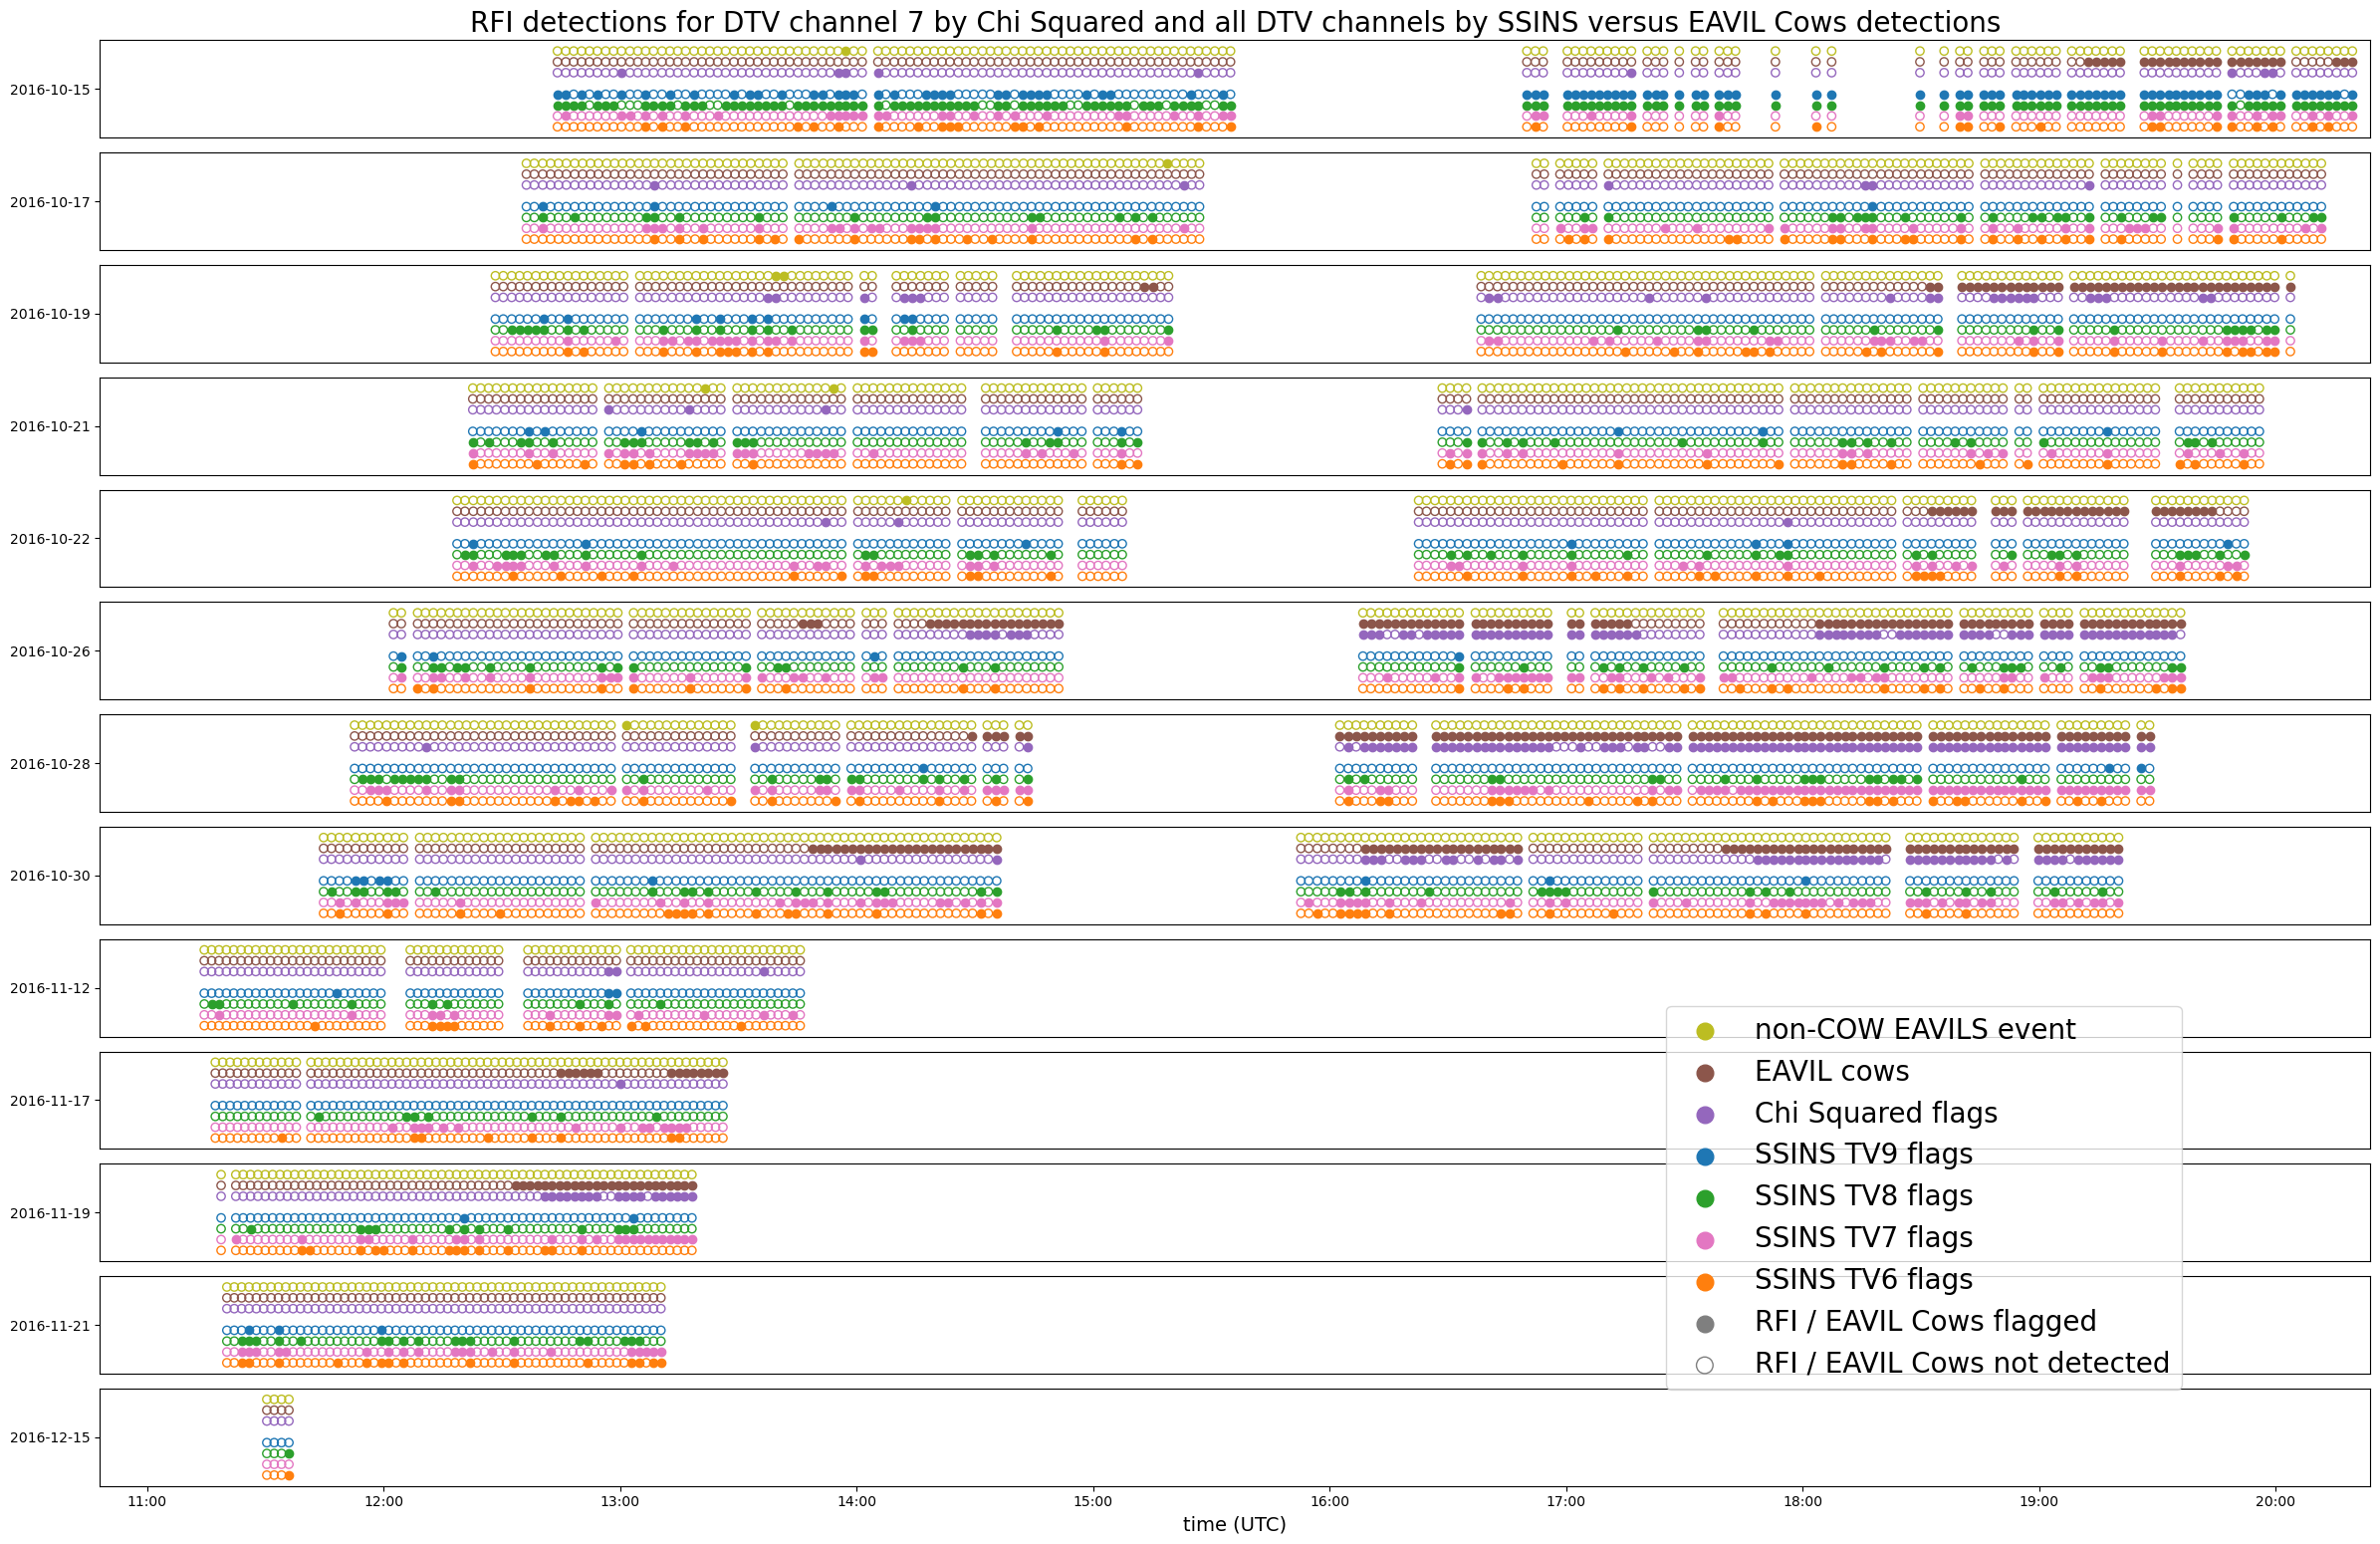

In [360]:
batchsizes = np.diff(np.where(np.diff(int_mjds, append=0, prepend=len(int_mjds)))[0])
nbatches = len(batchsizes)
fig, ax = plt.subplots(nbatches, 1, layout='tight', figsize=(24, nbatches*1.2))


if nbatches ==1:
    ax = [ax]
for i, batchsize in enumerate(batchsizes):
    
    x = np.arange(np.max(batchsizes))  # the label locations

    for j in range(batchsize):
        center_x, center_y = j, 0.9
        non_cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:olive'}
        cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:brown'}
        chisq_kwargs = {'facecolors':'none', 'edgecolors':'tab:purple'}
       
        ssins_tv9_kwargs = {'facecolors':'none', 'edgecolors':'tab:blue'}
        ssins_tv8_kwargs = {'facecolors':'none', 'edgecolors':'tab:green'}
        ssins_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:pink'}
        ssins_tv6_kwargs = {'facecolors':'none', 'edgecolors':'tab:orange'}

        index = np.sum(batchsizes[:i]) + j

        if cows_df.loc[:, "non cow EAVILS event "][index] == 1:
            non_cows_kwargs['facecolors'] = 'tab:olive'
            
        if cows_df.loc[:, "COWS"][index] == 1:
            cows_kwargs['facecolors'] = 'tab:brown'
            
        if cows_df.loc[:, "CHISQ"][index]== 1:
            chisq_kwargs['facecolors'] = 'tab:purple'

        if cows_df.loc[:, "SSINS TV9 flags"][index] != 0:
            ssins_tv9_kwargs['facecolors'] = 'tab:blue'

        if cows_df.loc[:, "SSINS TV8 flags"][index]  != 0:
            ssins_tv8_kwargs['facecolors'] = 'tab:green'

        if cows_df.loc[:, "SSINS TV7 flags"][index]  != 0: 
            ssins_tv7_kwargs['facecolors'] = 'tab:pink'

        if cows_df.loc[:, "SSINS TV6 flags"][index]  != 0:
            ssins_tv6_kwargs['facecolors'] = 'tab:orange'

           
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.7, **non_cows_kwargs) # cows
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.6, **cows_kwargs) # cows
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.5, **chisq_kwargs) # chisq

        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.3, **ssins_tv9_kwargs) # ssins tv9
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.2, **ssins_tv8_kwargs) # ssins tv8
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.1, **ssins_tv7_kwargs) # ssins tv7
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y, **ssins_tv6_kwargs) # ssins tv6
    ax[i].set_ylim(0.8, 1.7)
    ax[i].set_xticks([])

    ax[i].set_xlim(0.45, 0.85)
    ax[i].set_yticks([1.25],[np.unique(days.to_value('iso', subfmt='date'))[i]])
    

ax[-1].set_xticks([i/24 for i in range(11,21)], times)
plt.xlabel('time (UTC)', fontsize=14)

ax[0].set_title('RFI detections for DTV channel 7 by Chi Squared and all DTV channels by SSINS versus EAVIL Cows detections', fontsize=20)
non_cows_dot = ax[-1].scatter([], [], color='tab:olive', marker='o', label='non-COW EAVILS event')
cows_dot = ax[-1].scatter([], [], color='tab:brown', marker='o', label='EAVIL cows')
chisq_dot = ax[-1].scatter([], [], color='tab:purple', marker='o', label='Chi Squared flags')

ssins_tv9_dot = ax[-1].scatter([], [], color='tab:blue', marker='o', label='SSINS TV9 flags')
ssins_tv8_dot = ax[-1].scatter([], [], color='tab:green', marker='o', label='SSINS TV8 flags')
ssins_tv7_dot = ax[-1].scatter([], [], color='tab:pink', marker='o', label='SSINS TV7 flags')
ssins_tv6_dot = ax[-1].scatter([], [], color='tab:orange', marker='o', label='SSINS TV6 flags')

filled_dot = ax[-1].scatter([], [], color='tab:gray', marker='o', label='RFI / EAVIL Cows flagged')
empty_dot = ax[-1].scatter([], [], color='tab:gray', facecolors='none', marker='o', label='RFI / EAVIL Cows not detected') 

fig.legend(handles=[non_cows_dot,cows_dot, chisq_dot, ssins_tv9_dot, ssins_tv8_dot, ssins_tv7_dot, ssins_tv6_dot, filled_dot, empty_dot], loc=(0.7,0.1), fontsize='20', markerscale=2)
plt.show()

#fig.savefig("eavil_cows_dotplot_updated_ssins.png", dpi=300, bbox_inches='tight')
# fig.savefig("eavil_cows_dotplot_updated.pdf")

We can see here that there is a lot of contaminated data. Let's take data from a night without manually flagged COWs, 10-17-2016, and use that as an estimate for what the standard deviation of the pol-subtracted metric should be for each channel and sky field. Note that we'll still need to exclude any obs IDs that were tagged with EAVILS events that are not COWs.

In [292]:
good_source_dict = {'EOR0':'10-17-2016-EOR0','EOR1':'10-17-2016-EOR1'}


In [316]:
non_cow_EAVILS_obs_list = cows_df['Obsid'][cows_df['non cow EAVILS event ']==True].astype(str)
non_cow_EAVILS_obs_list

36      1160575016
232     1160752712
362     1160919552
363     1160919672
531     1161091272
546     1161093224
732     1161180728
1059    1161694880
1073    1161696832
Name: Obsid, dtype: object

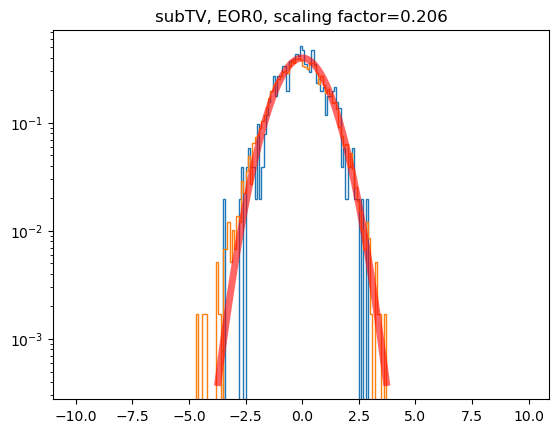

subTV 0.20642177600773748


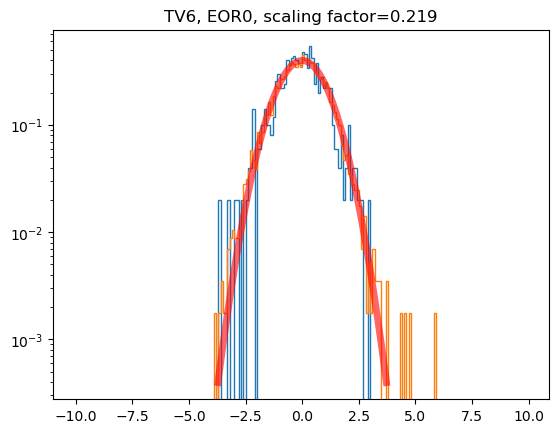

TV6 0.21888826618972923


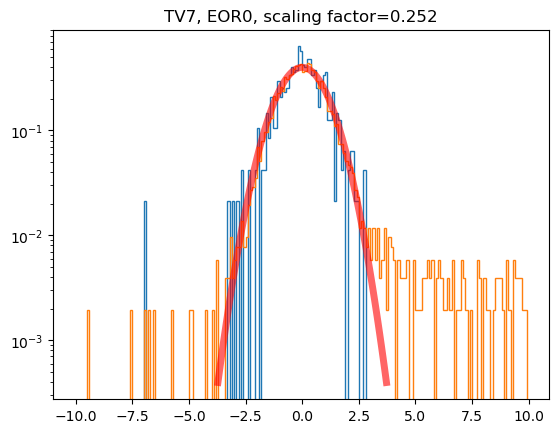

TV7 0.25237745580544174


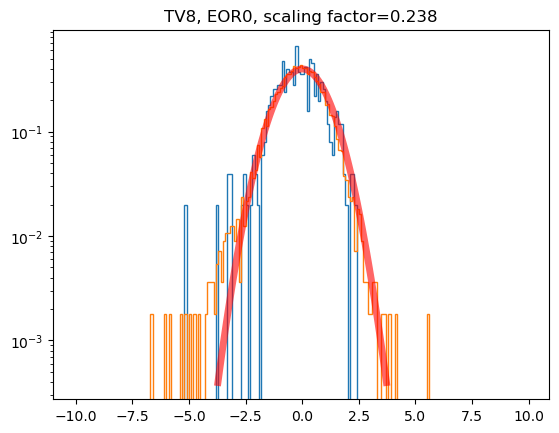

TV8 0.23768252002210125


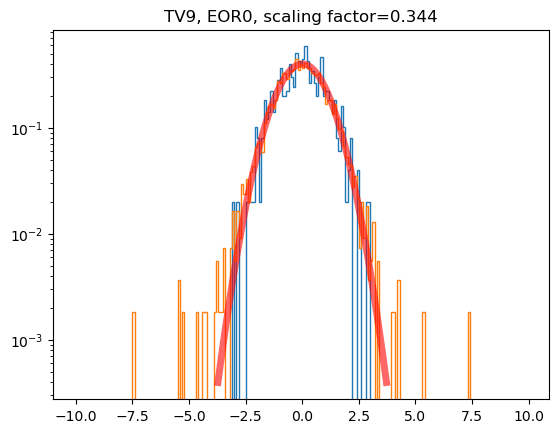

TV9 0.34433548513618567


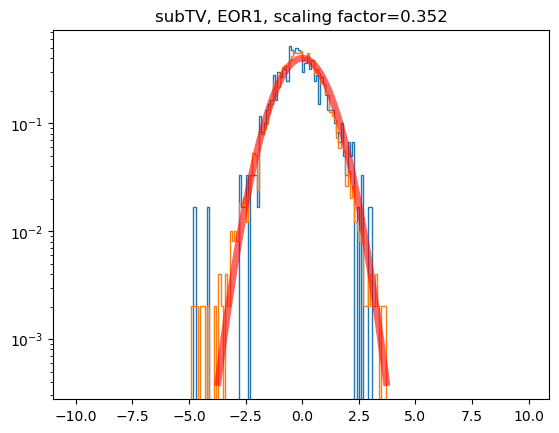

subTV 0.3517692235879413


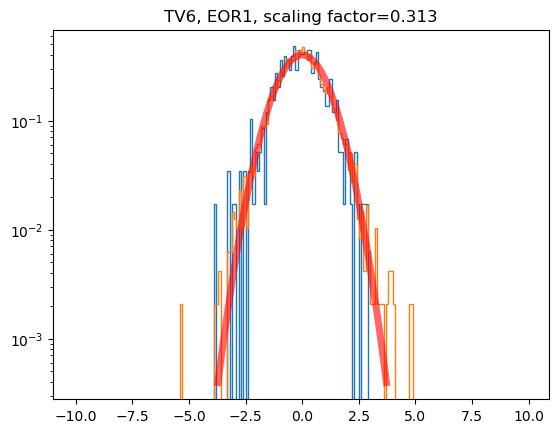

TV6 0.3131892011272576


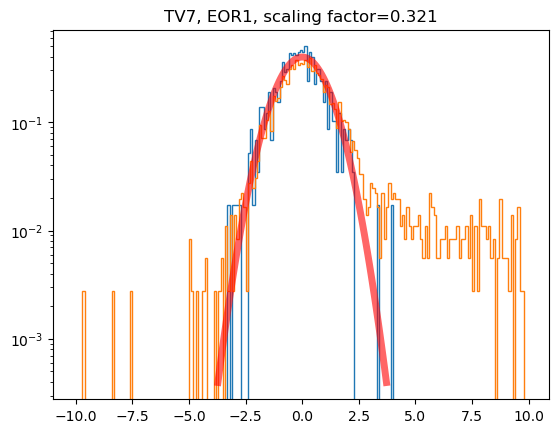

TV7 0.32103032783427293


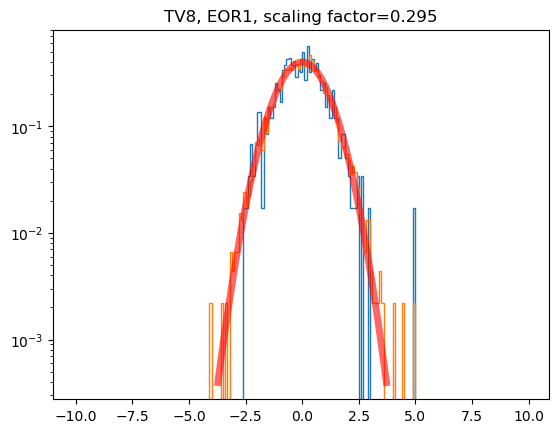

TV8 0.29514659355796546


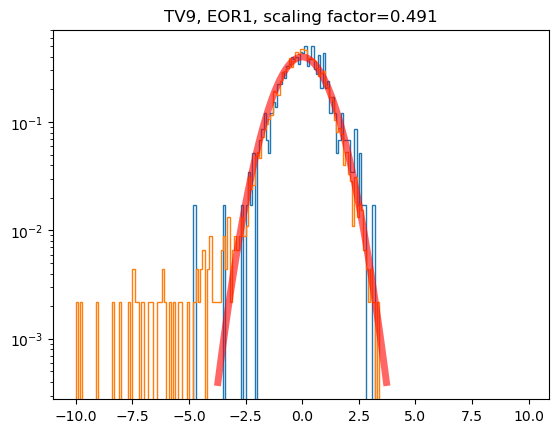

TV9 0.4914488492397479


In [318]:
initial_estimated_pol_sub_stdv= {sky_field:{} for sky_field in sky_field_list}



for sky_field in sky_field_list:
    for freq_range in sorted_freq_ranges:
        
        good_source_list = good_source_dict[sky_field]
        query_string_clean = f'source_list==\'{good_source_list}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
        
        pol_sub_series_clean = datafr[~datafr['obs_id'].isin(non_cow_EAVILS_obs_list)].query(query_string_clean)['pol_sub']

        scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
        
        initial_estimated_pol_sub_stdv[sky_field][freq_range] = scaling

        
        pol_sub_series = datafr.query(f'{'sky_field'}==\'{sky_field}\' & {'freq_range'}==\'{freq_range}\' & {'SSINS_flagged'}=={False}')['pol_sub']
        channel_dof = dof_ref_dict[freq_range]
       
    
        plt.yscale('log')
        
        plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step')
        
        plt.hist((pol_sub_series)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step')
        x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                    scipy.stats.norm.ppf(0.9999,scale=1), 100)
        plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                'r-', lw=5, alpha=0.6, label='standard normal pdf')
        plt.title(f'{freq_range}, {sky_field}, scaling factor={np.round(scaling,3)}')
        plt.show()
        print(freq_range,scaling)

In [319]:
initial_estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.20642177600773748,
  'TV6': 0.21888826618972923,
  'TV7': 0.25237745580544174,
  'TV8': 0.23768252002210125,
  'TV9': 0.34433548513618567},
 'EOR1': {'subTV': 0.3517692235879413,
  'TV6': 0.3131892011272576,
  'TV7': 0.32103032783427293,
  'TV8': 0.29514659355796546,
  'TV9': 0.4914488492397479}}

Note that the TV9 channel has a markedly higher standard deviation. This is expected, because fewer frequencies are present in that channel within the frequency range the MWA is observing at for this dataset. Thus, fewer values go into the calculation of the variance for each measurement, and so the distribution of variances is wider, and thus the difference between variances between polarizations tends to be higher!

## Here we establish a threshold for flagging
 on some simple assumptions on what we want our 

In [54]:
scipy.stats.norm.isf(.001/(5*100)) #False positive rate/(num_freq_channels * approx number of meas. per pointing)

4.611382362302668

In [326]:
threshold = 4.61

With this initial estimate in mind, we'd like to incorporate more data into our estimate. We thus use our initial estimate as a basis for identifying any pointing that has at least one measurement cross our predetermined threshold in a given frequency range. This is a conservative way to make sure our data is likely to be contamination free. We then get a new estimate of our standard deviation for each pol-subtracted distribution, check against the threshold again, and repeat until our estimates don't change.

iterations: 0
10-15-2016-EOR0
10-15-2016-EOR1
10-17-2016-EOR0
10-17-2016-EOR1
10-19-2016-EOR0
10-19-2016-EOR1
10-21-2016-EOR0
10-21-2016-EOR1
10-22-2016-EOR0
10-22-2016-EOR1
10-26-2016-EOR0
10-26-2016-EOR1
10-28-2016-EOR0
10-28-2016-EOR1
10-30-2016-EOR0
10-30-2016-EOR1
11-12-2016-EOR0
11-17-2016-EOR0
11-19-2016-EOR0
11-21-2016-EOR0
12-15-2016-EOR0
EOR0 subTV estimate shifted by 0.015459590501006093
EOR0 TV6 estimate shifted by 0.00515761030829559
EOR0 TV7 estimate shifted by -0.01018631534661485
EOR0 TV8 estimate shifted by -0.003229706664083287
EOR0 TV9 estimate shifted by 0.016287202367314735
EOR1 subTV estimate shifted by -0.02431863408883067
EOR1 TV6 estimate shifted by 0.004392408392237146
EOR1 TV7 estimate shifted by 0.01115896988197912
EOR1 TV8 estimate shifted by 0.0026948310092055894
EOR1 TV9 estimate shifted by -0.033444162858561666
{'EOR0': {'subTV': 0.22188136650874357, 'TV6': 0.22404587649802482, 'TV7': 0.2421911404588269, 'TV8': 0.23445281335801796, 'TV9': 0.3606226875035

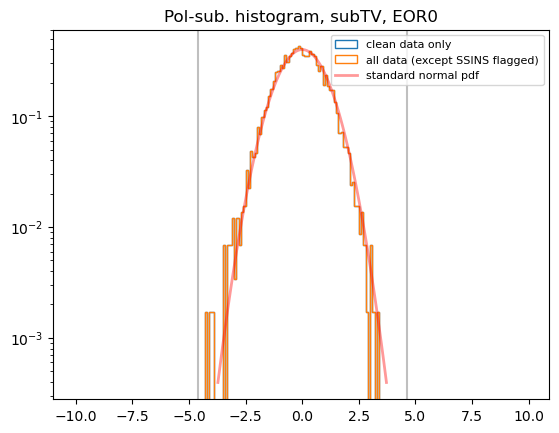

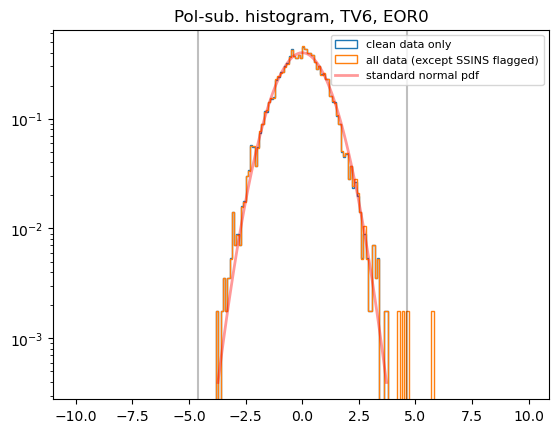

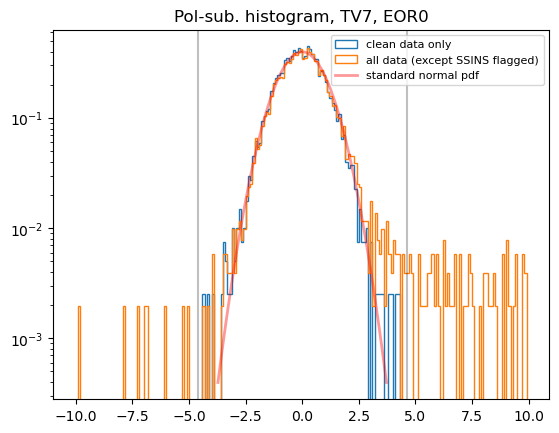

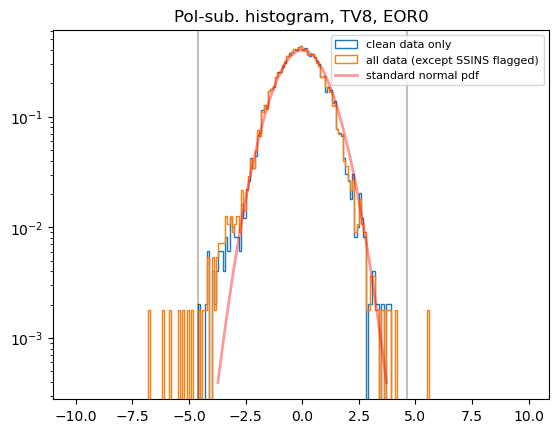

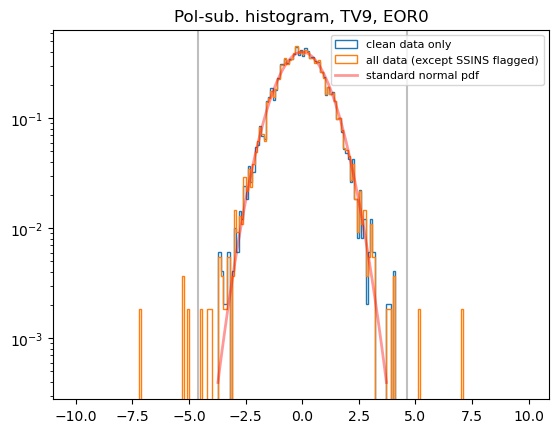

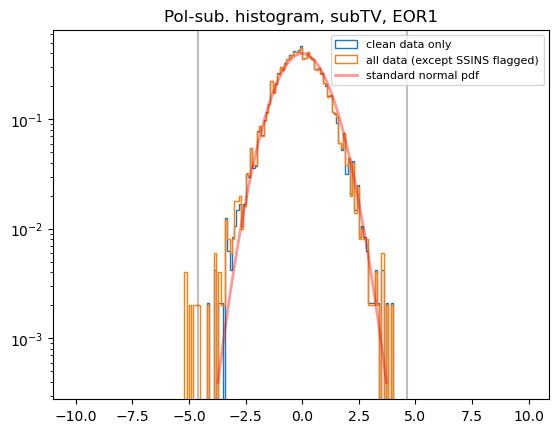

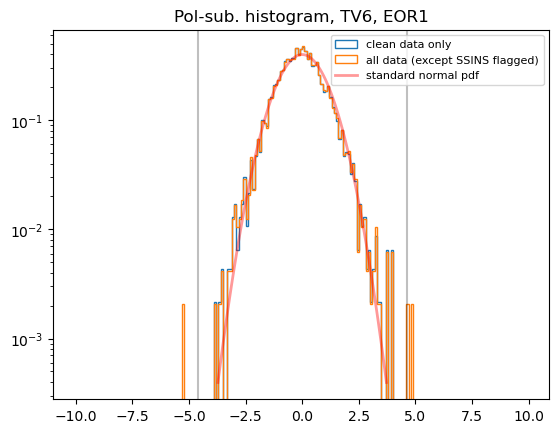

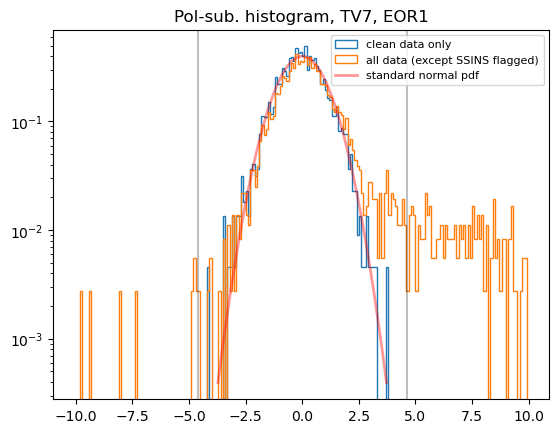

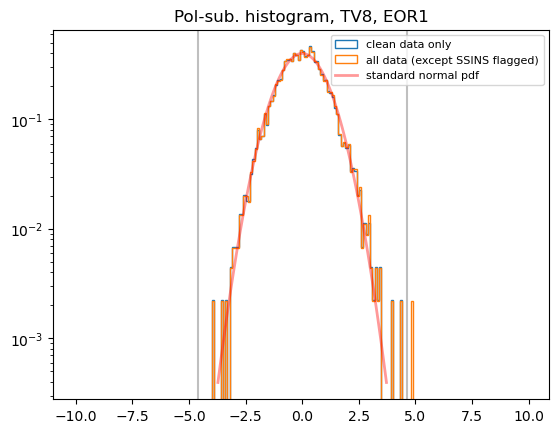

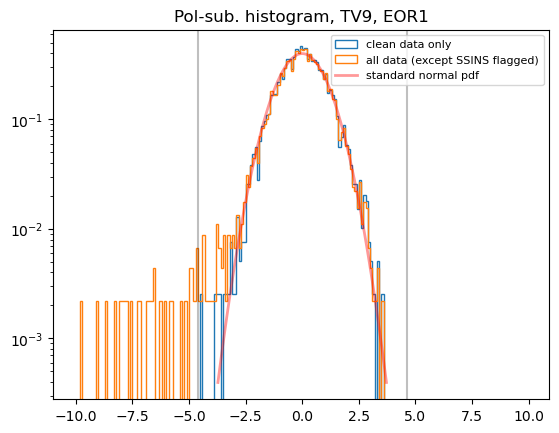

In [495]:
iteration_count=0

datafr['pointing_flagged'] = False #This should already be true, but ensures it's the case

estimated_pol_sub_stdv = copy.deepcopy(initial_estimated_pol_sub_stdv)
while True:
    print('iterations:',iteration_count)
    prev_estimated_pol_sub_stdv = copy.deepcopy(estimated_pol_sub_stdv)
    
    for source_list in np.unique(datafr.source_list):
        print(source_list)
        sky_field = sky_field_list_association[source_list]

        for pointing in np.unique(datafr.pointing):
            for freq_range in sorted_freq_ranges:
                query_string = f'sky_field==\'{sky_field}\' & source_list==\'{source_list}\' & pointing=={pointing} & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                sub_series = datafr.query(query_string)['pol_sub']
                estimated_stdv = estimated_pol_sub_stdv[sky_field][freq_range]
                outliers = np.abs(sub_series)>(estimated_stdv*threshold)
    
                if np.sum(outliers)>0:
                    flag_pointing=True
                else:
                    flag_pointing=False
                if flag_pointing:
                    flagged_indices = datafr.query(query_string).index
                    datafr.loc[flagged_indices,'pointing_flagged'] = True
    
    
    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
            pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
    
            scaling = np.sqrt(np.var(pol_sub_series_clean,ddof=1))
            
            estimated_pol_sub_stdv[sky_field][freq_range] = scaling

    for sky_field in sky_field_list:
        for freq_range in sorted_freq_ranges:
            print(sky_field,freq_range,'estimate shifted by', estimated_pol_sub_stdv[sky_field][freq_range] - prev_estimated_pol_sub_stdv[sky_field][freq_range])
    print(estimated_pol_sub_stdv) 
    if estimated_pol_sub_stdv==prev_estimated_pol_sub_stdv:    
        for sky_field in sky_field_list:
            for freq_range in sorted_freq_ranges:
                query_string_all = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False}'
                pol_sub_series_all = datafr.query(query_string_all)['pol_sub']
                
                query_string_clean = f'sky_field==\'{sky_field}\' & freq_range==\'{freq_range}\'& SSINS_flagged=={False} & pointing_flagged=={False}'
                pol_sub_series_clean = datafr.query(query_string_clean)['pol_sub']
                plt.yscale('log')
                
                scaling = estimated_pol_sub_stdv[sky_field][freq_range]
                
                plt.hist((pol_sub_series_clean)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='clean data only')
                plt.hist((pol_sub_series_all)/scaling,bins=np.arange(-10,10,.1),density=True,histtype='step',label='all data (except SSINS flagged)')
                plt.vlines([-threshold,threshold],ymin=0,ymax=1,color='black',alpha=.25)
                
                x = np.linspace(scipy.stats.norm.ppf(0.0001,scale=1),
                                                            scipy.stats.norm.ppf(0.9999,scale=1), 100)
                plt.plot(x, scipy.stats.norm.pdf(x,scale=1),
                        'r-', lw=2, alpha=0.4, label='standard normal pdf')
                plt.title(f'Pol-sub. histogram, {freq_range}, {sky_field}')
                plt.legend( prop={'size': 8})
                plt.show()
        break
    iteration_count+=1
           

In [337]:
estimated_pol_sub_stdv

{'EOR0': {'subTV': 0.22188136650874357,
  'TV6': 0.22404587649802482,
  'TV7': 0.2421911404588269,
  'TV8': 0.23445281335801796,
  'TV9': 0.3606226875035004},
 'EOR1': {'subTV': 0.32745058949911066,
  'TV6': 0.31758160951949477,
  'TV7': 0.33218929771625205,
  'TV8': 0.29784142456717105,
  'TV9': 0.4567150812528031}}

In [630]:
flagged_obs_ids={freq_range:[] for freq_range in sorted_freq_ranges}
flagged_no_SSINS_obs_ids={freq_range:[] for freq_range in sorted_freq_ranges}
SSINS_flagged_obs_ids={freq_range:[] for freq_range in sorted_freq_ranges}
SSINS_majority_obs_ids = {freq_range:[] for freq_range in sorted_freq_ranges}

for sky_field in sky_field_list:
    for freq_range in sorted_freq_ranges:
        query_string = f'sky_field==\'{sky_field}\'   & freq_range==\'{freq_range}\''
        
        for include_SSINS_flagged_data in [True,False]:
            if include_SSINS_flagged_data:
                query_mod = ''
            else:
                query_mod = '& SSINS_flagged==False'
            sub_series = datafr.query(query_string+query_mod)['pol_sub']
            estimated_stdv = estimated_pol_sub_stdv[sky_field][freq_range]
            outliers = np.abs(sub_series)>(estimated_stdv*threshold)
            if include_SSINS_flagged_data:
                flagged_obs_ids[freq_range]+=list( np.unique(datafr.query(query_string+query_mod)[outliers==True]['obs_id']))
            else:
                flagged_no_SSINS_obs_ids[freq_range]+=list( np.unique(datafr.query(query_string+query_mod)[outliers==True]['obs_id']))
        
        
        SSINS_flagged_obs_ids[freq_range]+=list( np.unique(datafr.query(query_string+'& SSINS_flagged==True')['obs_id']))

        
        SSINS_flag_counts = datafr.query(query_string+'& SSINS_flagged==True')['obs_id'].value_counts()
        SSINS_majority_obs_ids[freq_range]+=SSINS_flag_counts[SSINS_flag_counts>3].index.tolist()

In [633]:

for freq_range in sorted_freq_ranges:
    cows_df[f'pol_sub_flagged_{freq_range}']=False
    flagged_list = flagged_obs_ids[freq_range]
    cows_df.loc[cows_df['Obsid'].isin(flagged_list),f'pol_sub_flagged_{freq_range}']=True

    cows_df[f'pol_sub_flagged_no_SSINS_{freq_range}']=False
    flagged_no_SSINS_list = flagged_no_SSINS_obs_ids[freq_range]
    cows_df.loc[cows_df['Obsid'].isin(flagged_no_SSINS_list),f'pol_sub_flagged_no_SSINS_{freq_range}']=True
    
    cows_df[f'better_SSINS_flagged_{freq_range}']=False
    SSINS_flagged_list = SSINS_flagged_obs_ids[freq_range]
    cows_df.loc[cows_df['Obsid'].isin(SSINS_flagged_list),f'better_SSINS_flagged_{freq_range}']=True

    cows_df[f'SSINS_majority_flagged_{freq_range}']=False
    SSINS_majority_list = SSINS_majority_obs_ids[freq_range]
    cows_df.loc[cows_df['Obsid'].isin(SSINS_majority_list),f'SSINS_majority_flagged_{freq_range}']=True

In [816]:
def percentage_formatter(subset_size, total_elements):
    if subset_size>0:
        percentage = (subset_size / total_elements) * 100
        return f"\n{subset_size}\n{percentage:.1f}%" # Format as raw_count (percentage%)
    else:
        return ""
        

In [825]:
len(cows_df)

1653

0.8037825059101655

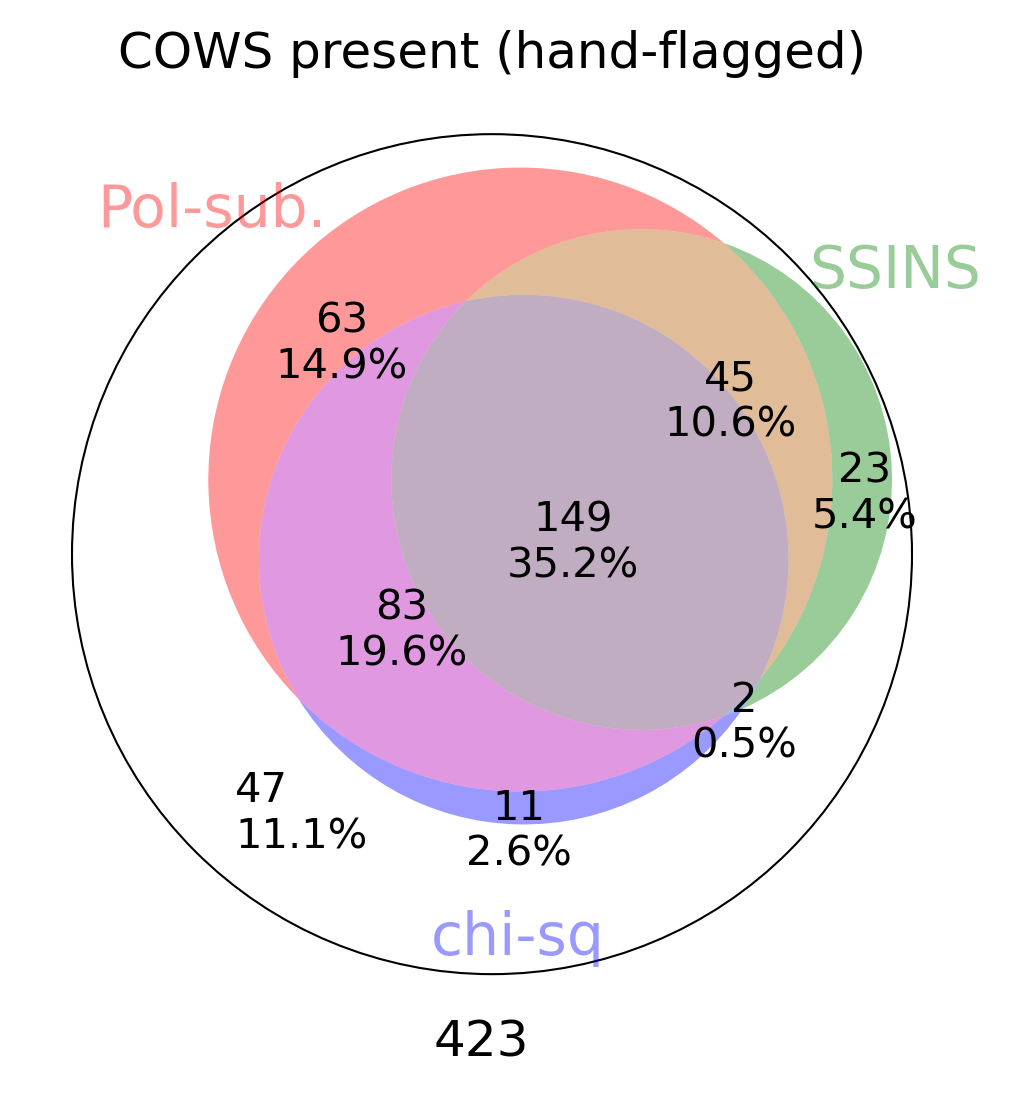

In [853]:

cows_df_local = copy.deepcopy(cows_df[cows_df['COWS']==True])
freq_range = 'TV7'
pol_flagged_set = set(cows_df_local['Obsid'][cows_df_local[f'pol_sub_flagged_{freq_range}']==True])
SSINS_flagged_set = set(cows_df_local['Obsid'][cows_df_local[f'better_SSINS_flagged_{freq_range}']==True])
chisq_set = set(cows_df_local['Obsid'][cows_df_local[f'CHISQ']==True])
total_union =len(pol_flagged_set.union(SSINS_flagged_set.union(chisq_set)))
grand_total = len(cows_df_local)
remaining = grand_total-total_union
plt.figure(figsize=(4,4),dpi=300)
out = matplotlib_venn.venn3([pol_flagged_set, SSINS_flagged_set, chisq_set], set_labels = ('Pol-sub.', 'SSINS', 'chi-sq'),
        subset_label_formatter=lambda x: percentage_formatter(x, grand_total))

number_label_size = 10
for text in out.subset_labels:
    text.set_fontsize(number_label_size)


ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

center_x = (xlim[0] + xlim[1]) / 2
center_y = (ylim[0] + ylim[1]) / 2
radius = (max(xlim[1] - xlim[0], ylim[1] - ylim[0]) / 2 )* 1.05
center_adjust = (-.1,-.1)
circle = Circle((center_x+center_adjust[0], center_y+center_adjust[1]), radius, fill=False, color='black', linewidth=.5)
ax.add_patch(circle)
ax.set_xlim(center_x+center_adjust[0] - radius * 1.1, center_x+center_adjust[0] + radius * 1.1)
ax.set_ylim(center_y+center_adjust[1] - radius * 1.1, center_y+center_adjust[1] + radius * 1.1)


label_x = center_x - radius * 0.75
label_y = center_y - radius * 0.7
ax.text(label_x, label_y, percentage_formatter(remaining,grand_total), fontsize=number_label_size, ha='left', va='center')

label_x = center_x -.2
label_y = center_y - radius * 1.3
ax.text(label_x, label_y, grand_total, fontsize=12, ha='left', va='center')


plt.title('COWS present (hand-flagged)',size=12)
color_list = []
for i, id in enumerate(['100', '010', '001']):
    patch = out.get_patch_by_id(id)
    if patch:
        color_list.append(patch.get_facecolor())
        
for idx, label in enumerate(out.set_labels):
    circle_color = color_list[idx]
    label.set_color(circle_color)  # Set label color to match
    label.set_fontsize(14)  # You can change font too
    pos = label.get_position()
    new_pos = (pos[0]*1.2, pos[1]-.1)  # Move vertically up by 0.2 units
    label.set_position(new_pos)
    

len(pol_flagged_set)/len(cows_df_local)

0.12357723577235773

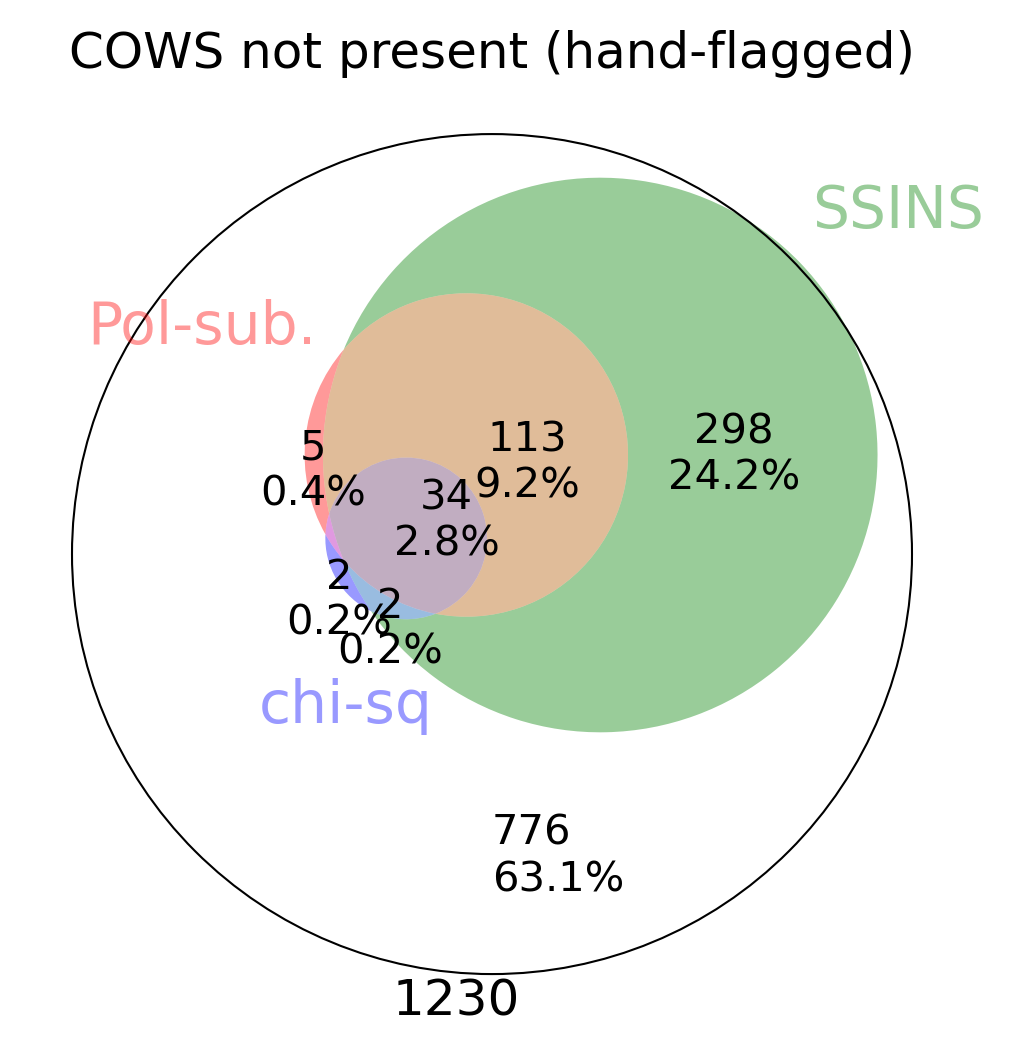

In [851]:
cows_df_local = copy.deepcopy(cows_df[cows_df['COWS']==False])
freq_range = 'TV7'
pol_flagged_set = set(cows_df_local['Obsid'][cows_df_local[f'pol_sub_flagged_{freq_range}']==True])
SSINS_flagged_set = set(cows_df_local['Obsid'][cows_df_local[f'better_SSINS_flagged_{freq_range}']==True])
chisq_set = set(cows_df_local['Obsid'][cows_df_local[f'CHISQ']==True])
total_union =len(pol_flagged_set.union(SSINS_flagged_set.union(chisq_set)))
grand_total = len(cows_df_local)
remaining = grand_total-total_union
plt.figure(figsize=(4,4),dpi=300)
out = matplotlib_venn.venn3([pol_flagged_set, SSINS_flagged_set, chisq_set], set_labels = ('Pol-sub.', 'SSINS', 'chi-sq'),
        subset_label_formatter=lambda x: percentage_formatter(x, grand_total))
number_label_size=10
for text in out.subset_labels:
    text.set_fontsize(number_label_size)

ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

center_x = (xlim[0] + xlim[1]) / 2
center_y = (ylim[0] + ylim[1]) / 2
radius = (max(xlim[1] - xlim[0], ylim[1] - ylim[0]) / 2 )* 1.25
center_adjust = (-.2,-.2)
circle = Circle((center_x+center_adjust[0], center_y+center_adjust[1]), radius, fill=False, color='black', linewidth=.5)
ax.add_patch(circle)
ax.set_xlim(center_x+center_adjust[0] - radius * 1.1, center_x+center_adjust[0] + radius * 1.1)
ax.set_ylim(center_y+center_adjust[1] - radius * 1.1, center_y+center_adjust[1] + radius * 1.1)


label_x = center_x -.2
label_y = center_y - radius * 0.9
ax.text(label_x, label_y, percentage_formatter(remaining,grand_total), fontsize=number_label_size, ha='left', va='center')

label_x = center_x -.4
label_y = center_y - radius * 1.3
ax.text(label_x, label_y, grand_total, fontsize=12, ha='left', va='center')


plt.title('COWS not present (hand-flagged)',size=12)
color_list = []
for i, id in enumerate(['100', '010', '001']):
    patch = out.get_patch_by_id(id)
    if patch:
        color_list.append(patch.get_facecolor())
        
for idx, label in enumerate(out.set_labels):
    circle_color = color_list[idx]
    label.set_color(circle_color)  # Set label color to match
    label.set_fontsize(14)  # You can change font too
    pos = label.get_position()
    new_pos = (pos[0]*1.4, pos[1]-.1)  # Move vertically up by 0.2 units
    label.set_position(new_pos)
    

len(pol_flagged_set)/len(cows_df_local)

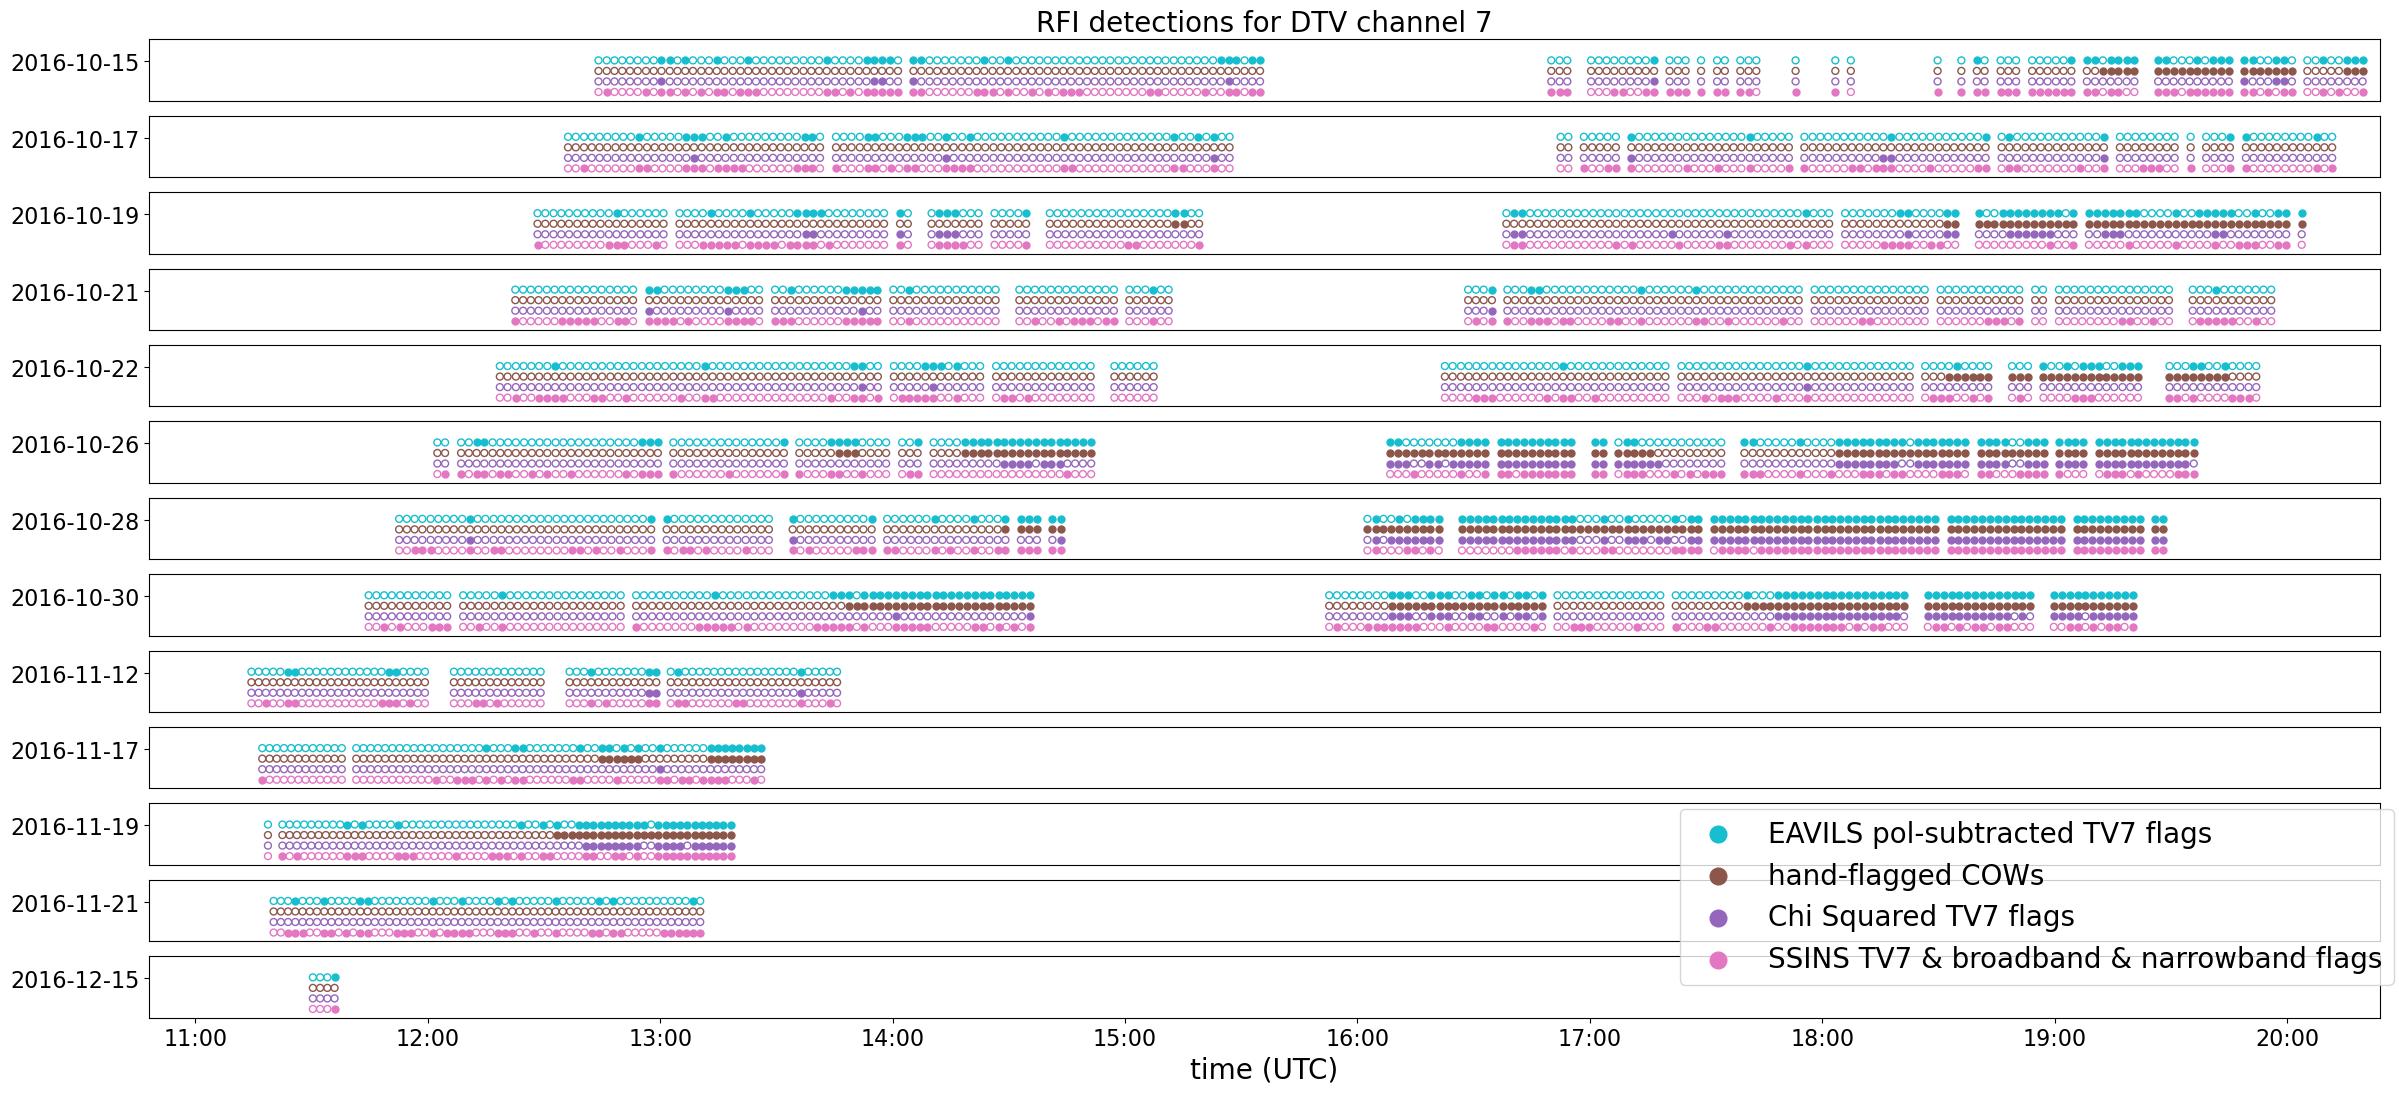

In [850]:
batchsizes = np.diff(np.where(np.diff(int_mjds, append=0, prepend=len(int_mjds)))[0])
nbatches = len(batchsizes)
fig, ax = plt.subplots(nbatches, 1, layout='tight', figsize=(24, nbatches*.85))



if nbatches ==1:
    ax = [ax]
for i, batchsize in enumerate(batchsizes):
    
    x = np.arange(np.max(batchsizes))  # the label locations

    for j in range(batchsize):
        center_x, center_y = j, 0.9
        non_cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:olive'}
        cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:brown'}
        chisq_kwargs = {'facecolors':'none', 'edgecolors':'tab:purple'}

        ssins_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:pink'}
        pol_sub_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:cyan'}
        
        index = np.sum(batchsizes[:i]) + j

        if cows_df.loc[:, "non cow EAVILS event "][index] == 1:
            non_cows_kwargs['facecolors'] = 'tab:olive'
            
        if cows_df.loc[:, "COWS"][index] == 1:
            cows_kwargs['facecolors'] = 'tab:brown'
            
        if cows_df.loc[:, "CHISQ"][index]== 1:
            chisq_kwargs['facecolors'] = 'tab:purple'



        if cows_df.loc[:, "better_SSINS_flagged_TV7"][index]  != 0: 
            ssins_tv7_kwargs['facecolors'] = 'tab:pink'


        if cows_df.loc[:, "pol_sub_flagged_TV7"][index]  == True: 
            pol_sub_tv7_kwargs['facecolors'] = 'tab:cyan'

        #if cows_df.loc[:, "SSINS_majority_flagged_TV7"][index] == True:
        #    pol_sub_tv7_kwargs['edgecolors']='none'
        spacing =.12
        kwarg_list = [pol_sub_tv7_kwargs,cows_kwargs,chisq_kwargs,ssins_tv7_kwargs]
        for ind,kwargs in enumerate(kwarg_list):
            ymod = (len(kwarg_list) - ind-1)*spacing
            ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + ymod, **kwargs, marker='o',s=25) 

        
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.3, **pol_sub_tv7_kwargs) 
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.2, **cows_kwargs) 
        
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.1, **chisq_kwargs) # chisq

        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.0, **ssins_tv7_kwargs) # ssins tv7
    #ax[i].set_ylim(0.8, 1.7)
    ax[i].set_ylim(0.8, 1.5)
    ax[i].set_xticks([])

    ax[i].set_xlim(0.45, 0.85)
    ax[i].set_yticks([1.25],[np.unique(days.to_value('iso', subfmt='date'))[i]],fontsize=16)
    

ax[-1].set_xticks([i/24 for i in range(11,21)], times,fontsize=16)
plt.xlabel('time (UTC)', fontsize=20)

ax[0].set_title('RFI detections for DTV channel 7', fontsize=20)
non_cows_dot = ax[-1].scatter([], [], color='tab:olive', marker='o', label='non-COW EAVILS event')
cows_dot = ax[-1].scatter([], [], color='tab:brown', marker='o', label='hand-flagged COWs')
chisq_dot = ax[-1].scatter([], [], color='tab:purple', marker='o', label='Chi Squared TV7 flags')

#ssins_tv9_dot = ax[-1].scatter([], [], color='tab:blue', marker='o', label='SSINS TV9 flags')
#ssins_tv8_dot = ax[-1].scatter([], [], color='tab:green', marker='o', label='SSINS TV8 flags')
ssins_tv7_dot = ax[-1].scatter([], [], color='tab:pink', marker='o', label='SSINS TV7 & broadband & narrowband flags')
#ssins_tv6_dot = ax[-1].scatter([], [], color='tab:orange', marker='o', label='SSINS TV6 flags')

pol_sub_tv7_dot = ax[-1].scatter([], [], color='tab:cyan', marker='o', label='EAVILS pol-subtracted TV7 flags')

#filled_dot = ax[-1].scatter([], [], color='tab:gray', marker='o', label='RFI / EAVIL Cows flagged')
#empty_dot = ax[-1].scatter([], [], color='tab:gray', facecolors='none', marker='o', label='RFI / EAVIL Cows not detected') 

fig.legend(handles=[ pol_sub_tv7_dot,cows_dot, chisq_dot, ssins_tv7_dot], loc=(0.7,0.1), fontsize='20', markerscale=2)
plt.show()

#fig.savefig("eavil_cows_dotplot_updated_ssins.png", dpi=300, bbox_inches='tight')
fig.savefig("example_plots/dotplot_updated.pdf")

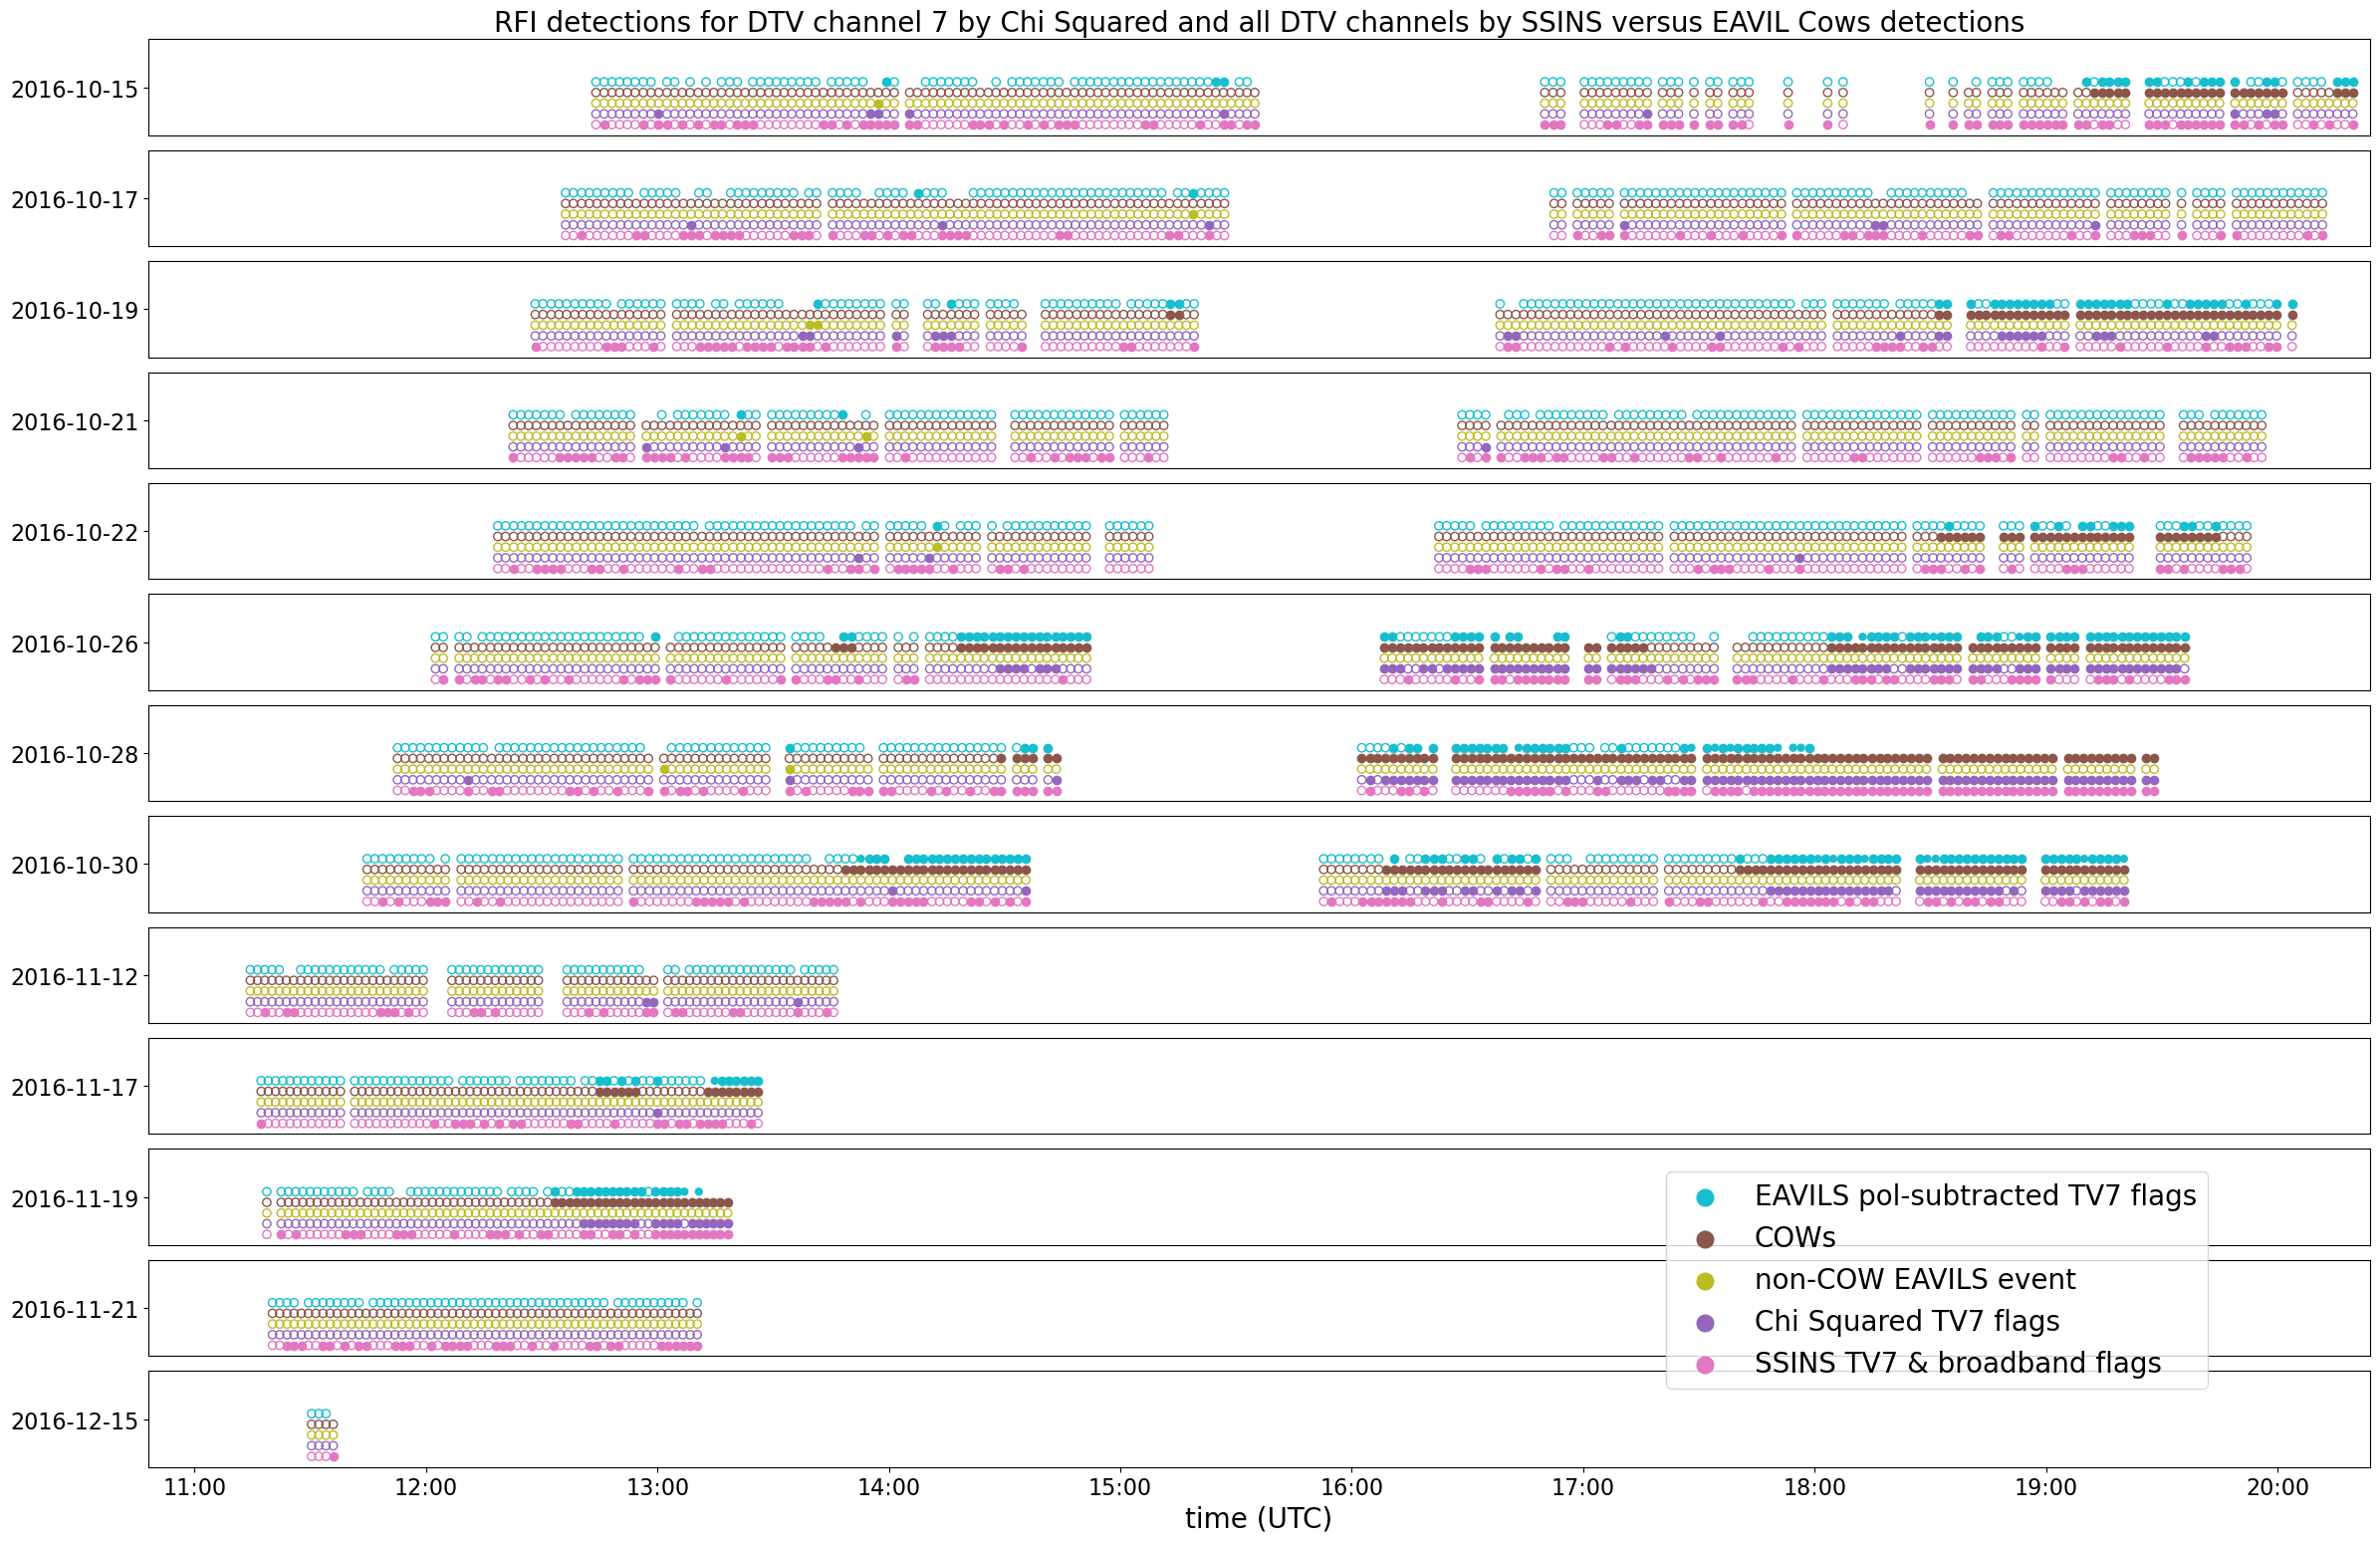

In [575]:
batchsizes = np.diff(np.where(np.diff(int_mjds, append=0, prepend=len(int_mjds)))[0])
nbatches = len(batchsizes)
fig, ax = plt.subplots(nbatches, 1, layout='tight', figsize=(24, nbatches*1.2))



if nbatches ==1:
    ax = [ax]
for i, batchsize in enumerate(batchsizes):
    
    x = np.arange(np.max(batchsizes))  # the label locations

    for j in range(batchsize):
        center_x, center_y = j, 0.9
        non_cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:olive'}
        cows_kwargs = {'facecolors':'none', 'edgecolors':'tab:brown'}
        chisq_kwargs = {'facecolors':'none', 'edgecolors':'tab:purple'}

        ssins_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:pink'}
        pol_sub_tv7_kwargs = {'facecolors':'none', 'edgecolors':'tab:cyan'}
        
        index = np.sum(batchsizes[:i]) + j

        if cows_df.loc[:, "non cow EAVILS event "][index] == 1:
            non_cows_kwargs['facecolors'] = 'tab:olive'
            
        if cows_df.loc[:, "COWS"][index] == 1:
            cows_kwargs['facecolors'] = 'tab:brown'
            
        if cows_df.loc[:, "CHISQ"][index]== 1:
            chisq_kwargs['facecolors'] = 'tab:purple'



        if cows_df.loc[:, "better_SSINS_flagged_TV7"][index]  != 0: 
            ssins_tv7_kwargs['facecolors'] = 'tab:pink'


        if cows_df.loc[:, "pol_sub_flagged_TV7"][index]  == True: 
            pol_sub_tv7_kwargs['facecolors'] = 'tab:cyan'

        if cows_df.loc[:, "SSINS_majority_flagged_TV7"][index] == True:
            pol_sub_tv7_kwargs['edgecolors']='none'

        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.4, **pol_sub_tv7_kwargs) 
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.3, **cows_kwargs) 
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.2, **non_cows_kwargs) # cows
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.1, **chisq_kwargs) # chisq

        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.3, **ssins_tv9_kwargs) # ssins tv9
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.2, **ssins_tv8_kwargs) # ssins tv8
        ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y + 0.0, **ssins_tv7_kwargs) # ssins tv7
        #ax[i].scatter(mjds[index] - np.floor(mjds[index]), center_y, **ssins_tv6_kwargs) # ssins tv6
    ax[i].set_ylim(0.8, 1.7)
    ax[i].set_xticks([])

    ax[i].set_xlim(0.45, 0.85)
    ax[i].set_yticks([1.25],[np.unique(days.to_value('iso', subfmt='date'))[i]],fontsize=16)
    

ax[-1].set_xticks([i/24 for i in range(11,21)], times,fontsize=16)
plt.xlabel('time (UTC)', fontsize=20)

ax[0].set_title('RFI detections for DTV channel 7 by Chi Squared and all DTV channels by SSINS versus EAVIL Cows detections', fontsize=20)
non_cows_dot = ax[-1].scatter([], [], color='tab:olive', marker='o', label='non-COW EAVILS event')
cows_dot = ax[-1].scatter([], [], color='tab:brown', marker='o', label='COWs')
chisq_dot = ax[-1].scatter([], [], color='tab:purple', marker='o', label='Chi Squared TV7 flags')

#ssins_tv9_dot = ax[-1].scatter([], [], color='tab:blue', marker='o', label='SSINS TV9 flags')
#ssins_tv8_dot = ax[-1].scatter([], [], color='tab:green', marker='o', label='SSINS TV8 flags')
ssins_tv7_dot = ax[-1].scatter([], [], color='tab:pink', marker='o', label='SSINS TV7 & broadband flags')
#ssins_tv6_dot = ax[-1].scatter([], [], color='tab:orange', marker='o', label='SSINS TV6 flags')

pol_sub_tv7_dot = ax[-1].scatter([], [], color='tab:cyan', marker='o', label='EAVILS pol-subtracted TV7 flags')

#filled_dot = ax[-1].scatter([], [], color='tab:gray', marker='o', label='RFI / EAVIL Cows flagged')
#empty_dot = ax[-1].scatter([], [], color='tab:gray', facecolors='none', marker='o', label='RFI / EAVIL Cows not detected') 

fig.legend(handles=[ pol_sub_tv7_dot,cows_dot, non_cows_dot,chisq_dot, ssins_tv7_dot], loc=(0.7,0.1), fontsize='20', markerscale=2)
plt.show()

#fig.savefig("eavil_cows_dotplot_updated_ssins.png", dpi=300, bbox_inches='tight')
fig.savefig("example_plots/dotplot_updated.pdf")

In [427]:
datafr= EAVILS_processing.add_pol_sub_stdv(datafr,estimated_pol_sub_stdv)

In [428]:
per_pointing_stats=EAVILS_processing.find_per_pointing_stats(datafr=datafr,shape_dict=shape_dict,list_titles=list_titles,threshold=threshold)


Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encountered in scalar divide
Mean of empty slice.
invalid value encou

In [741]:

importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/11-19-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('variance','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2),
                                  ('variance','YY','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               restricted_list=['1163593984','1163594096','1163594208','1163594320'],
                               line_plot_freq_ranges=['subTV','TV7']
                              )

pointing = 1
1163593984
1163594096
1163594208
1163594320
saving example_plots/11-19-2016-EOR0_Tdim8_Fdim1restricted_ptng_1_EAVILS.pdf


In [742]:



importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-19-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('variance','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2),
                                  ('variance','YY','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               restricted_list=['1160937608','1160937728','1160937848','1160937976']
                              )

pointing = 1
1160937608
1160937728
1160937848
1160937976
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1restricted_ptng_1_EAVILS.pdf


In [552]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-17-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1160758328
1160758448
1160758688
1160758816
1160758936
1160759056
1160759184
saving example_plots/10-17-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1160759424
1160759544
1160759672
1160759792
1160759912
1160760032
1160760152
1160760280
1160760400
1160760520
1160760640
1160760768
1160760888
1160761008
1160761128
saving example_plots/10-17-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1160761256
1160761376
1160761496
1160761616
1160761744
1160761864
1160762104
1160762232
1160762352
1160762472
1160762600
1160762720
1160762840
1160762960
saving example_plots/10-17-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1160763088
1160763208
1160763328
1160763448
1160763576
1160763696
1160763816
1160763936
1160764056
1160764184
1160764304
1160764424
1160764544
1160764672
1160764792
1160764912
saving example_plots/10-17-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1160765160
1160765280
1160765400
1160765528
1160765648
1160765768
1160765888
1160766016
1160766136
1160

In [553]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-19-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1160930288
1160930408
1160930536
1160930656
1160930776
1160930896
1160931016
1160931144
1160931264
1160931384
1160931504
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1160931632
1160931752
1160931872
1160931992
1160932120
1160932240
1160932360
1160932480
1160932608
1160932728
1160932848
1160932968
1160933096
1160933216
1160933336
1160933456
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1160933584
1160933704
1160933824
1160933944
1160934072
1160934192
1160934312
1160934440
1160934560
1160934680
1160934800
1160934928
1160935048
1160935168
1160935288
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1160935536
1160935656
1160935776
1160935896
1160936024
1160936144
1160936264
1160936384
1160936512
1160936632
1160936752
1160936872
1160937000
1160937120
1160937240
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1160937608
1160937728
1160937848
1160937976
1160

In [554]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-26-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1161518528
1161518648
1161518896
1161519016
1161519136
1161519256
1161519384
1161519504
1161519624
1161519744
1161519872
1161519992
1161520112
1161520232
1161520360
saving example_plots/10-26-2016-EOR0_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1161520480
1161520600
1161520720
1161520848
1161520968
1161521088
1161521208
1161521336
1161521456
1161521576
1161521696
1161521824
1161521944
1161522184
1161522312
saving example_plots/10-26-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1161522432
1161522552
1161522672
1161522800
1161522920
1161523040
1161523160
1161523288
1161523408
1161523528
1161523648
1161523776
1161523896
1161524136
saving example_plots/10-26-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1161524264
1161524384
1161524504
1161524624
1161524752
1161524872
1161524992
1161525112
1161525240
1161525360
1161525480
1161525728
1161525848
1161525968
saving example_plots/10-26-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1161526216
1161526336
1161526456
1161

In [480]:
# importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-28-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False
                              )


pointing = -3
1161705736
1161705864
1161705984
1161706104
1161706224
1161706352
1161706472
1161706592
1161706712
1161706840
1161706960
saving example_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1161707200
1161707328
1161707448
1161707568
1161707688
1161707816
1161707936
1161708056
1161708176
1161708304
1161708424
1161708544
1161708664
1161708792
1161708912
saving example_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
pointing = -1
1161709032
1161709152
1161709280
1161709400
1161709520
1161709640
1161709768
1161709888
1161710008
1161710128
1161710256
1161710376
1161710496
1161710616
1161710744
saving example_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1161710864
1161711104
1161711232
1161711352
1161711472
1161711592
1161711720
1161711840
1161711960
1161712080
1161712208
1161712328
1161712448
1161712568
1161712696
saving example_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1161712816
1161712936
1161713056
1161713184
1

In [481]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/11-19-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False
                              )


pointing = -2
1163589504
1163589728
1163589840
1163589952
1163590064
1163590176
1163590288
saving example_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
pointing = -1
1163590400
1163590512
1163590624
1163590736
1163590848
1163590960
1163591072
1163591184
1163591296
1163591408
1163591520
1163591632
1163591744
1163591856
1163591968
1163592080
saving example_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1163592192
1163592304
1163592416
1163592528
1163592640
1163592752
1163592864
1163592976
1163593088
1163593200
1163593312
1163593424
1163593536
1163593648
1163593760
1163593872
saving example_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1163593984
1163594096
1163594208
1163594320
1163594432
1163594544
1163594656
1163594768
1163594880
1163594992
1163595104
1163595216
1163595328
1163595440
1163595552
1163595664
1163595776
saving example_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_1_EAVILS.pdf
pointing = 2
1163595888
1163596000
1163596112
1163596224
116

In [482]:
# importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/11-19-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False
                              )


pointing = -2
1163589504
1163589728
1163589840
1163589952
1163590064
1163590176
1163590288
saving example_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
pointing = -1
1163590400
1163590512
1163590624
1163590736
1163590848
1163590960
1163591072
1163591184
1163591296
1163591408
1163591520
1163591632
1163591744
1163591856
1163591968
1163592080
saving example_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1163592192
1163592304
1163592416
1163592528
1163592640
1163592752
1163592864
1163592976
1163593088
1163593200
1163593312
1163593424
1163593536
1163593648
1163593760
1163593872
saving example_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1163593984
1163594096
1163594208
1163594320
1163594432
1163594544
1163594656
1163594768
1163594880
1163594992
1163595104
1163595216
1163595328
1163595440
1163595552
1163595664
1163595776
saving example_plots/11-19-2016-EOR0_Tdim8_Fdim1_ptng_1_EAVILS.pdf
pointing = 2
1163595888
1163596000
1163596112
1163596224
116

In [679]:
cows_df.keys()

Index(['Obsid', 'COWS', 'CHISQ', 'SSINS', 'non cow EAVILS event ', 'Notes',
       'mjd', 'SSINS TV6 flags', 'SSINS TV7 flags', 'SSINS TV8 flags',
       'SSINS TV9 flags', 'SSINS narrow flags', 'SSINS streak flags',
       'SSINS total flags', 'pol_sub_flagged_subTV', 'pol_sub_flagged_TV6',
       'pol_sub_flagged_TV7', 'pol_sub_flagged_TV8', 'pol_sub_flagged_TV9',
       'better_SSINS_flagged_subTV', 'better_SSINS_flagged_TV6',
       'better_SSINS_flagged_TV7', 'better_SSINS_flagged_TV8',
       'better_SSINS_flagged_TV9', 'SSINS_majority_flagged_subTV',
       'SSINS_majority_flagged_TV6', 'SSINS_majority_flagged_TV7',
       'SSINS_majority_flagged_TV8', 'SSINS_majority_flagged_TV9',
       'pol_sub_flagged_no_SSINS_subTV', 'pol_sub_flagged_no_SSINS_TV6',
       'pol_sub_flagged_no_SSINS_TV7', 'pol_sub_flagged_no_SSINS_TV8',
       'pol_sub_flagged_no_SSINS_TV9'],
      dtype='object')

In [715]:
freq_range = 'TV7'
weird_obs = list(cows_df.query(f'COWS==False & better_SSINS_flagged_{freq_range}==False & pol_sub_flagged_{freq_range} == True & CHISQ == False')['Obsid'])
sorted([(obs,source_list_dict[obs],info['pointing']) for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])

[('1160580264', '10-15-2016-EOR0', 2),
 ('1160748440', '10-17-2016-EOR0', -1),
 ('1160752712', '10-17-2016-EOR0', 2),
 ('1160919672', '10-19-2016-EOR0', -1),
 ('1161180728', '10-22-2016-EOR0', 0)]

In [689]:
freq_range = 'TV7'
weird_obs = list(cows_df.query(f'COWS==False &  pol_sub_flagged_no_SSINS_{freq_range} == True')['Obsid'])
auto_list = sorted([(obs,source_list_dict[obs],info['pointing'],'auto') for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])
weird_obs = list(cows_df[cows_df['non cow EAVILS event ']==True]['Obsid'])
hand_list = sorted([(obs,source_list_dict[obs],info['pointing'],'hand') for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])
comb_list = sorted(auto_list+hand_list)
comb_list

[('1160575016', '10-15-2016-EOR0', -1, 'hand'),
 ('1160575136', '10-15-2016-EOR0', -1, 'auto'),
 ('1160580264', '10-15-2016-EOR0', 2, 'auto'),
 ('1160580384', '10-15-2016-EOR0', 2, 'auto'),
 ('1160593808', '10-15-2016-EOR1', 1, 'auto'),
 ('1160748440', '10-17-2016-EOR0', -1, 'auto'),
 ('1160752712', '10-17-2016-EOR0', 2, 'auto'),
 ('1160752712', '10-17-2016-EOR0', 2, 'hand'),
 ('1160919552', '10-19-2016-EOR0', -1, 'hand'),
 ('1160919672', '10-19-2016-EOR0', -1, 'auto'),
 ('1160919672', '10-19-2016-EOR0', -1, 'hand'),
 ('1160921752', '10-19-2016-EOR0', 0, 'auto'),
 ('1161091272', '10-21-2016-EOR0', -2, 'auto'),
 ('1161091272', '10-21-2016-EOR0', -2, 'hand'),
 ('1161092856', '10-21-2016-EOR0', -1, 'auto'),
 ('1161093224', '10-21-2016-EOR0', -1, 'hand'),
 ('1161180728', '10-22-2016-EOR0', 0, 'auto'),
 ('1161180728', '10-22-2016-EOR0', 0, 'hand'),
 ('1161521944', '10-26-2016-EOR0', -2, 'auto'),
 ('1161694880', '10-28-2016-EOR0', -1, 'hand'),
 ('1161696832', '10-28-2016-EOR0', 0, 'auto'),
 

In [675]:


freq_range = 'TV7'
weird_obs = list(cows_df[cows_df['non cow EAVILS event ']==True]['Obsid'])
sorted([(obs,source_list_dict[obs],info['pointing']) for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])

[('1160575016', '10-15-2016-EOR0', -1),
 ('1160752712', '10-17-2016-EOR0', 2),
 ('1160919552', '10-19-2016-EOR0', -1),
 ('1160919672', '10-19-2016-EOR0', -1),
 ('1161091272', '10-21-2016-EOR0', -2),
 ('1161093224', '10-21-2016-EOR0', -1),
 ('1161180728', '10-22-2016-EOR0', 0),
 ('1161694880', '10-28-2016-EOR0', -1),
 ('1161696832', '10-28-2016-EOR0', 0)]

In [719]:
freq_range = 'TV7'
weird_obs = list(cows_df.query(f'COWS==True & better_SSINS_flagged_{freq_range}==False & pol_sub_flagged_{freq_range} == False & CHISQ == True')['Obsid'])
sorted([(obs,source_list_dict[obs],info['pointing']) for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])

[('1161533536', '10-26-2016-EOR1', -3),
 ('1161533896', '10-26-2016-EOR1', -3),
 ('1161534024', '10-26-2016-EOR1', -3),
 ('1161534264', '10-26-2016-EOR1', -3),
 ('1161536824', '10-26-2016-EOR1', -1),
 ('1161537312', '10-26-2016-EOR1', -1),
 ('1161706104', '10-28-2016-EOR1', -3),
 ('1161709888', '10-28-2016-EOR1', -1),
 ('1161710008', '10-28-2016-EOR1', -1),
 ('1161710256', '10-28-2016-EOR1', -1),
 ('1161710376', '10-28-2016-EOR1', -1)]

In [720]:
freq_range = 'TV7'
weird_obs = list(cows_df.query(f'COWS==False & better_SSINS_flagged_{freq_range}==False & pol_sub_flagged_{freq_range} == False & CHISQ == True')['Obsid'])
sorted([(obs,source_list_dict[obs],info['pointing']) for obs,info in EAVILS_processing.pointing_identification([metafits_folders],weird_obs).items()])

[('1160932848', '10-19-2016-EOR1', -2), ('1161537440', '10-26-2016-EOR1', -1)]

In [598]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-15-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1160570624
1160570752
1160570872
1160570992
1160571112
1160571232
1160571360
1160571480
1160571600
1160571728
1160571848
1160571968
1160572088
1160572216
1160572336
1160572456
1160572576
saving example_plots/10-15-2016-EOR0_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1160572704
1160572824
1160572944
1160573064
1160573184
1160573312
1160573432
1160573552
1160573672
1160573800
1160573920
1160574040
1160574160
1160574288
1160574408
1160574528
saving example_plots/10-15-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1160574656
1160574776
1160574896
1160575016
1160575136
1160575264
1160575384
1160575504
1160575624
1160575752
1160575872
1160575992
1160576112
1160576240
1160576360
saving example_plots/10-15-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1160576480
1160576600
1160576728
1160576848
1160576968
1160577096
1160577216
1160577336
1160577456
1160577584
1160577704
1160577824
1160577944
1160578072
1160578192
saving example_plots/10-15-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS

In [683]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-15-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1160585384
1160585512
1160585632
1160585752
1160585872
1160586000
1160586120
1160586240
1160586360
1160586488
1160586608
1160586728
1160586848
saving example_plots/10-15-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1160586976
1160587096
1160587216
1160587344
1160587464
1160587584
1160587704
1160587832
1160587952
1160588072
1160588192
1160588312
1160588440
1160588560
1160588680
1160588800
saving example_plots/10-15-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1160589168
1160589288
1160589416
1160589536
1160589784
1160589904
1160590024
1160590144
1160590392
1160590512
1160590632
saving example_plots/10-15-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1160591120
1160591248
1160591368
1160591608
1160591736
1160591856
1160591976
1160592096
1160592216
1160592344
1160592464
1160592584
saving example_plots/10-15-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1160592832
1160592952
1160593072
1160593200
1160593320
1160593440
1160593680
1160593808
1160593928
1160

In [592]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-17-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1160742952
1160743072
1160743200
1160743320
1160743440
1160743560
1160743688
1160743808
1160743928
1160744048
1160744176
1160744296
1160744416
1160744536
1160744664
1160744784
1160744904
saving example_plots/10-17-2016-EOR0_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1160745024
1160745152
1160745272
1160745392
1160745520
1160745640
1160745760
1160745880
1160746008
1160746128
1160746248
1160746368
1160746496
1160746616
1160746736
1160746856
saving example_plots/10-17-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1160747104
1160747224
1160747344
1160747472
1160747592
1160747712
1160747832
1160747952
1160748080
1160748200
1160748320
1160748440
1160748568
1160748688
saving example_plots/10-17-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1160748808
1160748928
1160749056
1160749176
1160749296
1160749416
1160749544
1160749664
1160749784
1160749912
1160750032
1160750152
1160750272
1160750392
1160750520
saving example_plots/10-17-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointi

In [596]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-19-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1160915280
1160915400
1160915528
1160915648
1160915768
1160915896
1160916016
1160916136
1160916256
1160916384
1160916504
1160916624
1160916744
1160916872
1160916992
1160917112
1160917232
saving example_plots/10-19-2016-EOR0_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1160917480
1160917600
1160917720
1160917840
1160917968
1160918088
1160918208
1160918336
1160918456
1160918576
1160918696
1160918816
1160918944
1160919064
1160919184
saving example_plots/10-19-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1160919304
1160919432
1160919552
1160919672
1160919792
1160919920
1160920040
1160920160
1160920280
1160920408
1160920528
1160920648
1160920896
1160921016
saving example_plots/10-19-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1160921384
1160921504
1160921624
1160921752
1160921872
1160921992
1160922112
1160922360
1160922480
1160922600
1160922728
1160922848
saving example_plots/10-19-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1160923216
1160923336
1160923456
1160

In [721]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-19-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1160930288
1160930408
1160930536
1160930656
1160930776
1160930896
1160931016
1160931144
1160931264
1160931384
1160931504
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1160931632
1160931752
1160931872
1160931992
1160932120
1160932240
1160932360
1160932480
1160932608
1160932728
1160932848
1160932968
1160933096
1160933216
1160933336
1160933456
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1160933584
1160933704
1160933824
1160933944
1160934072
1160934192
1160934312
1160934440
1160934560
1160934680
1160934800
1160934928
1160935048
1160935168
1160935288
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1160935536
1160935656
1160935776
1160935896
1160936024
1160936144
1160936264
1160936384
1160936512
1160936632
1160936752
1160936872
1160937000
1160937120
1160937240
saving example_plots/10-19-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1160937608
1160937728
1160937848
1160937976
1160

In [676]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-21-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1161087736
1161087856
1161087976
1161088096
1161088224
1161088344
1161088464
1161088584
1161088712
1161088832
1161088952
1161089072
1161089200
1161089320
1161089440
1161089560
saving example_plots/10-21-2016-EOR0_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1161089808
1161089928
1161090048
1161090176
1161090296
1161090416
1161090536
1161090664
1161090784
1161090904
1161091024
1161091152
1161091272
1161091392
1161091512
saving example_plots/10-21-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1161091760
1161091880
1161092000
1161092128
1161092248
1161092368
1161092488
1161092616
1161092736
1161092856
1161092976
1161093104
1161093224
1161093344
saving example_plots/10-21-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1161093592
1161093712
1161093832
1161093952
1161094080
1161094200
1161094320
1161094440
1161094568
1161094688
1161094808
1161094928
1161095056
1161095176
saving example_plots/10-21-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1161095544
1161095664
1161

In [597]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-22-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1161173896
1161174016
1161174144
1161174264
1161174384
1161174504
1161174632
1161174752
1161174872
1161174992
1161175120
1161175240
1161175360
1161175480
1161175608
1161175728
saving example_plots/10-22-2016-EOR0_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1161175848
1161175968
1161176096
1161176216
1161176336
1161176456
1161176584
1161176704
1161176824
1161176944
1161177072
1161177192
1161177312
1161177432
1161177560
1161177680
saving example_plots/10-22-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1161177800
1161177920
1161178048
1161178168
1161178288
1161178408
1161178536
1161178656
1161178776
1161178896
1161179024
1161179144
1161179264
1161179384
1161179512
saving example_plots/10-22-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1161179632
1161179752
1161180000
1161180120
1161180240
1161180360
1161180488
1161180608
1161180728
1161180848
1161180976
1161181096
1161181216
1161181336
saving example_plots/10-22-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1161

In [677]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-28-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1161690736
1161690856
1161690976
1161691096
1161691224
1161691344
1161691464
1161691584
1161691712
1161691832
1161691952
1161692072
1161692200
1161692320
1161692440
1161692560
1161692688
saving example_plots/10-28-2016-EOR0_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1161692808
1161692928
1161693048
1161693176
1161693296
1161693416
1161693536
1161693664
1161693784
1161693904
1161694024
1161694152
1161694272
1161694392
1161694512
1161694640
saving example_plots/10-28-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1161694880
1161695000
1161695128
1161695248
1161695368
1161695488
1161695616
1161695736
1161695856
1161695976
1161696104
1161696224
1161696344
1161696464
saving example_plots/10-28-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1161696832
1161696952
1161697080
1161697200
1161697320
1161697440
1161697568
1161697688
1161697808
1161697928
1161698056
1161698296
saving example_plots/10-28-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1161698416
1161698544
1161

In [682]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/11-17-2016-EOR0.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -2
1163416616
1163416728
1163416840
1163416952
1163417064
1163417176
1163417288
1163417400
1163417512
1163417624
1163417736
1163417848
saving example_plots/11-17-2016-EOR0_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1163418072
1163418184
1163418296
1163418408
1163418520
1163418632
1163418744
1163418856
1163418968
1163419080
1163419192
1163419304
1163419416
1163419528
1163419640
1163419752
saving example_plots/11-17-2016-EOR0_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1163419864
1163419976
1163420088
1163420200
1163420312
1163420424
1163420536
1163420648
1163420760
1163420872
1163420984
1163421096
1163421208
1163421320
1163421432
1163421544
saving example_plots/11-17-2016-EOR0_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1163421656
1163421768
1163421880
1163421992
1163422104
1163422216
1163422328
1163422440
1163422552
1163422664
1163422776
1163422888
1163423000
1163423112
1163423224
1163423336
1163423448
saving example_plots/11-17-2016-EOR0_Tdim8_Fdim1_ptng_1_EAVILS.pdf
pointing = 2
116342

In [717]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-26-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1161533288
1161533408
1161533536
1161533656
1161533776
1161533896
1161534024
1161534144
1161534264
1161534384
1161534512
1161534632
saving example_plots/10-26-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1161534752
1161534872
1161535000
1161535120
1161535240
1161535360
1161535488
1161535608
1161535728
1161535848
1161535976
1161536096
1161536216
1161536336
1161536464
1161536584
saving example_plots/10-26-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1161536824
1161536952
1161537072
1161537192
1161537312
1161537440
1161537560
1161537680
1161537800
1161537928
1161538048
1161538168
1161538288
1161538416
saving example_plots/10-26-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1161538776
1161538904
1161539024
1161539144
1161539264
1161539392
1161539512
1161539632
1161539752
1161539880
1161540000
1161540120
1161540240
1161540368
saving example_plots/10-26-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1161540488
1161540608
1161540728
1161540856
1161540976
1161

In [718]:
importlib.reload(EAVILS_processing)

integration_time=2 #2 second integration time
time_buffer =120 #approximate time between observations (just used for plotting spacing)
EAVILS_processing.create_plots(list_file =  'example_obs_lists_split/10-28-2016-EOR1.txt',array_dict=array_dict,per_pointing_stats=per_pointing_stats,dof_ref_dict = dof_ref_dict,
                               input_directory='/Volumes/Data3/elillesk/data_and_analysis/vis_plt_outputs/chisq_obs/h5_files',
                               processed_data_directory=processed_data_directory, time_dim=time_dim,freq_dim=freq_dim,
                               shape_dict=shape_dict,sky_field_list_association=sky_field_list_association,metafits_folders=metafits_folders,
                               pol_bidict=pol_bidict,threshold=threshold,estimated_pol_sub_stdv = estimated_pol_sub_stdv,permanent_flags=permanent_flags,
                               time_buffer=time_buffer,
                               output_directory='example_plots',
                               integration_time=integration_time,
                               pre_flag_on_SSINS_masks=False,
                              plot_instructions= [
                                  ('EAVILS','XX','raster',1), 
                                   ('SSINS','XX','raster',1),
                                  ('EAVILS','YY','raster',1),
                                  ('SSINS','YY','raster',1),
                                  ('SSINS mask','XX','raster',1),
                                  ('pol_sub','XX-YY','line_plot',2)
                                 ],
                               display_pointing_changes=False,
                               split_on_pointings=True,
                               display_stats=False,
                               line_plot_freq_ranges=['subTV','TV7']
                              )


pointing = -3
1161705736
1161705864
1161705984
1161706104
1161706224
1161706352
1161706472
1161706592
1161706712
1161706840
1161706960
saving example_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_-3_EAVILS.pdf
pointing = -2
1161707200
1161707328
1161707448
1161707568
1161707688
1161707816
1161707936
1161708056
1161708176
1161708304
1161708424
1161708544
1161708664
1161708792
1161708912
saving example_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_-2_EAVILS.pdf
1161709032
1161709152
1161709280
1161709400
1161709520
1161709640
1161709768
1161709888
1161710008
1161710128
1161710256
1161710376
1161710496
1161710616
1161710744
saving example_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_-1_EAVILS.pdf
pointing = 0
1161710864
1161711104
1161711232
1161711352
1161711472
1161711592
1161711720
1161711840
1161711960
1161712080
1161712208
1161712328
1161712448
1161712568
1161712696
saving example_plots/10-28-2016-EOR1_Tdim8_Fdim1_ptng_0_EAVILS.pdf
pointing = 1
1161712816
1161712936
1161713056
1161713184
1161713304
1161